In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.optimize
import scipy.stats
from scipy.integrate import quad
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import copy
import calendar
from optimise_GDD_fctns import * #Phenology_set, run_GDD_and_get_RMSE, run_GDD_and_get_RMSE_derivs, plot_profiles_at_minimum, get_station_locations, put_ERA5_in_array

#import seaborn as sns

import plotting
import dataset_fctns
import modelling_fctns
import seaborn as sns
#from dwd_phenpy import Phenology_set

#import openeo
#import ee
## Trigger the authentication flow.
#ee.Authenticate()#(auth_mode='localhost')
# Initialize the library.
#ee.Initialize(project='ee-martinparker637')

c:\Users\wlwc1989\Documents\Phenology_Test_Notebooks\phenology_dwd\optimisation_experiments\optimise_GDD_fctns.py:35: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  station_data = pd.read_csv("https://opendata.dwd.de/climate_environment/CDC/help/PH_Beschreibung_Phaenologie_Stationen_Jahresmelder.txt",sep = ";\s+|;\t+|;\s+\t+|;\t+\s+|;|\s+;|\t+;|\s+\t+;|\t+\s+;", encoding='cp1252', on_bad_lines='skip')


In [2]:
def train_test_by_year(ds, test_years):
    obs_for_testing = ds['year'].isin(test_years)
    train_ds = ds[~obs_for_testing]
    test_ds = ds[obs_for_testing]
    return train_ds, test_ds

In [3]:
def plot_from_comparison_array(comparison_array, title_extra='', method='scatter', savename = False, phase_list = ['beginning of flowering'], exclude_unfinished = False, growing_period_length = 300, col = 'blue'):
    if method == 'both':
        fig, axs = plt.subplots(len(phase_list), 2, figsize = (10, len(phase_list)*5))
    else:
        fig, axs = plt.subplots(1, len(phase_list), figsize = (len(phase_list)*5, 5))
    for phase_index, phase in enumerate(phase_list):
        number_unfinished = (comparison_array[f'modelled time to {phase}'] >= growing_period_length).sum()
        number_total = len(comparison_array)
        print(f'{number_unfinished} stations out of {number_total} did not reach the end of phase \'{phase}\'')
        if exclude_unfinished:
            comparison_array = comparison_array[comparison_array[f'modelled time to {phase}'] < growing_period_length].dropna()
        #comparison_array[f'observed time to {phase}'] = comparison_array[f'observed time to {phase}'].dt.days
        if len(phase_list) == 1:
            ax = axs
        else:
            ax = axs[phase_index]
        if method == 'regression':
            #x_estimator=np.mean,
            #minval = min(comparison_array[f'observed time to {phase}'].min(), comparison_array[f'modelled time to {phase}'].min()) - 1
            #maxval = max(comparison_array[f'observed time to {phase}'].max(), comparison_array[f'modelled time to {phase}'].max()) + 1
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 2.5), color=col)
            axs.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            axs.set_xlim(minval, maxval)
            axs.set_ylim(minval, maxval)
            axs.set_title(f'Modelled and observed time to {phase}\n{title_extra}')
        elif method == 'errors':
            comparison_array['error'] = comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']
            sns.regplot(x=f'modelled time to {phase}', y='error', data=comparison_array, ax=axs,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(30, 200, 5))
            axs.set_title(f'Comparison of fitted values and residuals {phase}\n{title_extra}')
        elif method == 'histogram':
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            axs.set_title(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting')
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.9))
            rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
            print(f'R^2 value for model: {rsquared}')
            bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
            variance_modelled = comparison_array[f'modelled time to {phase}'].var()
            print(f'Bias: {bias**2}\nVariance of modelled values: {variance_modelled}')
        elif method == 'both':
            ax = axs[0]
            minval = min(comparison_array[f'observed time to {phase}'].quantile(0.05), comparison_array[f'modelled time to {phase}'].quantile(0.05)) - 1
            maxval = max(comparison_array[f'observed time to {phase}'].quantile(0.95), comparison_array[f'modelled time to {phase}'].quantile(0.95)) + 1
            sns.regplot(x=f'modelled time to {phase}', y=f'observed time to {phase}', data=comparison_array, ax=ax,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=np.arange(minval - 5, maxval + 5, 5))
            ax.plot([minval, maxval], [minval, maxval], linestyle='--', color='k', lw=1, scalex=False, scaley=False)
            ax.set_xlim(minval, maxval)
            ax.set_ylim(minval, maxval)
            
            ax = axs[1]
            sns.histplot(x=f'modelled time to {phase}', data = comparison_array, ax=ax, label = 'modelled days to anthesis',
                        stat = 'density')
            sns.histplot(x=f'observed time to {phase}', data = comparison_array, ax=ax, label= 'observed days to anthesis',
                        stat = 'density')
            sns.set(font_scale=1.5)
            fig.suptitle(f'Comparison of GDD modelled and observed time to\n{phase} {title_extra}')
            ax.set_xlabel('Days after planting', fontsize = 18)
            ax.set_ylabel('Density', fontsize = 18)
            #ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
            fig.legend(bbox_to_anchor = (1.2, 0.8))
            fig.tight_layout()
    rsquared = r2_score(comparison_array[f'observed time to {phase}'], comparison_array[f'modelled time to {phase}'])
    print(f'R^2 value for model: {rsquared}')
    bias = comparison_array[f'observed time to {phase}'].mean() - comparison_array[f'modelled time to {phase}'].mean()
    variance_modelled = comparison_array[f'modelled time to {phase}'].var()
    print(f'Bias: {bias**2} (sign {np.sign(bias)})\nVariance of modelled values: {variance_modelled}')
    if savename != False:
        fig.savefig(f'plots/{savename}', bbox_inches='tight')

In [4]:
def run_GDD_and_get_RMSE_derivs(x, ds, driver_variable = 't2m', latlon_proj = True, response_type = 'Trapezoid', 
                                phase_list = ['beginning of flowering'],growing_period_length = 300,
                                thresholds = [100]):
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])

    ## Initiate development time storage object - a list with a value for all the stations, that will change over time and be stored in a list.
    t_dev = np.zeros(len(ds)) #Continuous development time. When this passes through some thresholds then have change in phase.
    accumulated_deriv_time_series = [[t_dev.copy()] for count in range(len(x))]
    dev_time_series = [t_dev.copy()]
    list_of_responses = [] 
    #Run model
    for day in range(growing_period_length):
        # Pull values for temperature out of data frame
        driver_values = ds[f'{driver_variable} at day {day}'].values
        resp = response(driver_values)
        # Calculate the response for each of these temperatures and add it to the total accumulated temperature
        if response_type == 'Trapezoid':
            response_deriv = x[0]*Trapezoid_Temp_derivs(driver_values, x[1], x[2], x[3], x[4])
            response_deriv[0, :] = response_deriv[0, :]/x[0]
        elif response_type == 'Wang':
            response_deriv_no_scale = Wang_Temp_Derivs(driver_values, x[1], x[2], x[3])
            response_deriv = [resp/x[0]] + [x[0]*deriv for deriv in response_deriv_no_scale]
        for x_index in range(len(x)):
            accumulated_deriv_time_series[x_index].append(accumulated_deriv_time_series[x_index][-1] + response_deriv[x_index])
        t_dev += resp#, t_dev)
        list_of_responses.append(resp)
        #print(len(accumulated_deriv_time_series[0][-1]))
        #print(accumulated_deriv_time_series[0][-1], t_dev/x[0])
        #Store the accumulated temperature in an array
        dev_time_series.append(t_dev.copy())

    # Add the year and station codes for indexing later and to check that extracting values didn't mix up indexes
    dev_time_series.append(ds['year'].values)
    dev_time_series.append(ds['Stations_id'].values)
    #print([p.shape for p in dev_time_series])
    model_dev_time_series = np.array(dev_time_series)
    #driver_array['Development Time'] = (('days from emergence', 'Emergence observation'), model_dev_time_series)
    column_names = np.concatenate([np.array([f'modelled time to {phase}' for phase in phase_list]), ['year'], ['Stations_id']])
    phase_dates_array = np.zeros((len(thresholds), model_dev_time_series.shape[1]))
    resps_list = np.zeros(model_dev_time_series.shape[1])
    for obs_index in range(model_dev_time_series.shape[1]):
        phase_dates_array[:, obs_index] = np.digitize(thresholds, model_dev_time_series[:-2, obs_index].astype(np.float64)) - 1
        resps_list[obs_index] = list_of_responses[int(phase_dates_array[-1, obs_index]) - 1][obs_index].mean()
    resps_list += 0.1*x[0]*(resps_list == 0)
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, [model_dev_time_series[-2]], [model_dev_time_series[-1]]], axis=0)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names)
    #phase_dates_array.iloc[:, :-1] = phase_dates_array.iloc[:, :-1].astype(int)
    #print(phase_dates_array.iloc[:, :-1])
    for x_index in range(len(x)):
        accumulated_derivs = accumulated_deriv_time_series[x_index]
        accumulated_derivs.append(ds['year'].values)
        accumulated_derivs.append(ds['Stations_id'].values)
        #print(accumulated_derivs[300])
        for phase in phase_list:
            accumulated_derivs.append(np.array(accumulated_derivs).T[np.arange(len(ds)), phase_dates_array[f'modelled time to {phase}'].values.astype(int)])
        column_names = np.array(['year', 'Stations_id'] + [f'x{x_index} deriv for {phase}'])
        #print(np.array(accumulated_derivs[301]))
        if x_index == 0:
            #derivs_array1 = pd.DataFrame(np.array(accumulated_derivs[301:]).T, columns = column_names)
            derivs_array = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            #print(derivs_array.shape)
        else:
            derivs_array2 = pd.DataFrame(np.array(accumulated_derivs[(growing_period_length + 1):]).T, columns = column_names)
            derivs_array = derivs_array.merge(derivs_array2, how='left', on=['year', 'Stations_id'])
            #print(derivs_array.shape)
    comparison_array = ds.merge(phase_dates_array, how='left', on=['year', 'Stations_id']).dropna(how='all')
    comparison_array = comparison_array.merge(derivs_array, on=['year', 'Stations_id'])
    def RMSE(residuals):
        return np.sqrt(np.mean(residuals**2))
    residuals = np.concatenate([(comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    error = RMSE(residuals)
    #print(len(residuals), len(comparison_array))
    #print(residuals)
    deriv_list = [
        -((comparison_array[f'modelled time to {only_phase}'] - comparison_array[f'observed time to {only_phase}'])*
         comparison_array[f'x{xindex} deriv for {only_phase}']/resps_list).mean()/error for xindex in range(len(x))#x[0]
         #(comparison_array['modelled time to yellow ripeness']/(1 + comparison_array[f'x{xindex} deriv for yellow ripeness']) - comparison_array['modelled time to yellow ripeness'])).sum() for xindex in range(len(x))
    ]
    return deriv_list#, resps_list#, comparison_array#, comparison_array, derivs_array, accumulated_deriv_time_series#, resps_list#, comparison_array, phase_dates_array, derivs_array, derivs_array2, derivs_array1


In [34]:
def local_opt(x1s, train, test, error_fctn = run_GDD_and_get_RMSE, lower_bounds = [0.05, 4, 20, 20, 35], upper_bounds = [1, 12, 35, 35, 60], #ds
              great_threshold = 13, response_type = 'Trapezoid', phase_list = ['yellow ripeness'],
              method = 'trust-constr', modified_cost = False, thresholds = [100], growing_period_length = 185,
              maxiter = 50, split = True, CCNN_split = False, test_size = 0.5, random_state=1, itr = 0.5, bias_term = False):
    #if split:
    #    train, test = train_test_split(ds, test_size=test_size, random_state = random_state)
    #    #train_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\temp_CCNN_training.csv')
    #elif CCNN_split:
    #    test_indices = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\model_output\\compare_CCNN_results.csv')
    #    train_indices = train_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test_indices = test_indices.rename(columns = {'year': 'Referenzjahr'})
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    complement_indices = ds.index.difference(test.index)
    #
    #    # Filter df2 to keep only the rows with the complement indices
    #    train = ds.loc[complement_indices]
    #    #train = pd.merge(ds, train_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #    test = pd.merge(ds, test_indices[['Stations_id', 'Referenzjahr']], on = ['Stations_id', 'Referenzjahr'])
    #else:
    #    train = ds
    #    test = ds
    only_phase = phase_list[0]
    if response_type == 'Trapezoid':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[4] - x[3]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0],
                                                [0, 0, -1, 1, 0],
                                                [0, 0, 0, -1, 1]])}
        constraints = scipy.optimize.LinearConstraint([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0], [0, 0, 0, -1, -1]], [0, 0, 0], [np.inf, np.inf, np.inf])
    elif response_type == 'Wang' or response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved_vary_spread':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, 0],
                                                [0, 0, -1, 1, 0, 0]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Convolved':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2]]),
                    'jac' : lambda x: np.array([[0, -1, 1, 0],
                                                [0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0, 0], [0, 0, -1, 1, 0, 0]]),lb= [0, 0], ub=[1000, 1000])
    elif response_type == 'Spline':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2],
                                                x[3]]),
                    'jac' : lambda x: np.array([[0 for count in range(20)],
                                                [0 for count in range(20)]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        constraints = scipy.optimize.LinearConstraint(np.array([[0 for count in range(20)], [0 for count in range(20)]]),lb= [-1, -1], ub=[1000, 1000])
    elif response_type == 'multi_phase':
        ineq_cons = {'type': 'ineq',
                    'fun' : lambda x: np.array([x[2] - x[1],
                                                x[3] - x[2],
                                                x[6] - x[5],
                                                x[7] - x[6]]
                                                ),
                    'jac' : lambda x: np.array([[0, -1, 1, 0, 0, -1, 1, 0],
                                                [0, 0, -1, 1, 0, 0, -1, 1]])}
        ieq_cons = [lambda x: x[2] - x[1],
                    lambda x: x[3] - x[2]]
        if bias_term:
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0, 0], [0, 0, -1, 1, 0]]),lb= [0, 0], ub=[1000, 1000])
        else:  
            constraints = scipy.optimize.LinearConstraint(np.array([[0, -1, 1, 0], [0, 0, -1, 1]]),lb= [0, 0], ub=[1000, 1000])
    bounds = scipy.optimize.Bounds(lb=lower_bounds, ub = upper_bounds)
    x0 = np.array([1, 4, 25, 35, 45])
    final_mins = []
    for x0 in x1s:
        if method == 'trust-constr':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list, 
                                                                         new_unfinished_penalisation=modified_cost, 
                                                                         growing_period_length = growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'trust-constr',#'COBYQA',
                                    jac='3-point',#
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', #jac='3-point',#[x0/1000 for x0 in 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#
                                    constraints=[constraints],
                                    options={'verbose': 3, 'initial_tr_radius': itr, 'xtol':1e-7, 'maxiter':maxiter},# ,'gtol':1e-7, 'finite_diff_rel_step': 0.05
                                    bounds=bounds, tol=1e-9)
        elif method == 'SLSQP':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'SLSQP',
                                    #jac = '3-point',
                                    jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                                                                response_type = response_type, 
                                                                                phase_list = phase_list, 
                                                                                growing_period_length=growing_period_length,
                                                                                thresholds = thresholds),#jac='3-point',#
                                    constraints=[ineq_cons],
                                    options={'disp': 3, 'maxiter':maxiter, 'ftol': 1e-16},
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Nelder-Mead':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Nelder-Mead',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True, 'fatol': 1e-10},#, 'maxiter':50
                                    bounds=bounds)#, tol=1e-15)
        elif method == 'Powell':
            res = scipy.optimize.minimize(lambda x: error_fctn(x, train, 't2m', 
                                                                         response_type = response_type, 
                                                                         phase_list = phase_list,
                                                                         new_unfinished_penalisation=modified_cost,
                                                                         growing_period_length=growing_period_length,
                                                                         thresholds = thresholds), 
                                    x0, method = 'Powell',
                                    #jac = '3-point',
                                    #jac = lambda x: run_GDD_and_get_RMSE_derivs(x, train, 't2m', 
                                    #                                            response_type = response_type, 
                                    #                                            phase_list = phase_list, 
                                    #                                            growing_period_length=growing_period_length,
                                    #                                            thresholds = thresholds),#jac='3-point',#
                                    options={'disp': True},#, 'maxiter':50
                                    bounds=bounds)
        print(x0, res.x, x0 - res.x)
        RMSE = error_fctn(res.x, test, 't2m', response_type = response_type, phase_list = phase_list, growing_period_length = growing_period_length, thresholds = thresholds)
        #print('R^2: ', r2_score(c_array[f'observed time to {only_phase}'], c_array[f'modelled time to {only_phase}']))
        print('RMSE at opt on test set: ', RMSE)
        print('R^2:', 1 - (RMSE**2/(test[f'observed time to {only_phase}'].var()*((len(test) - 1)/len(test)))))
        final_mins.append(res.x)
    return final_mins, res, train, test

In [96]:
def run_GDD(x, ds, driver_variable, latlon_proj = True, response_type = 'Trapezoid', 
                             phase_list = ['beginning of flowering'], exclude_unfinished = False,
                             growing_period_length = 300, thresholds = [100], 
                             title_extra='', method='scatter', savename = False, plot=False, col='blue',
                             index_cols = ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year'],
                             step = 0.5): 
    #Change index_cols to ['year', 'Stations_id'] if using DE dataset
    len_index_cols = len(index_cols)
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], 0.2, 3)#x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
    elif response_type == 'Convolved':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), 8, 3)#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], 3)
        table = scipy.ndimage.gaussian_filter(table2, 8/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
    elif response_type == 'Convolved_vary_spread':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], x[5])
        table = scipy.ndimage.gaussian_filter(table2, x[4]*10/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
        #def response(meantemp):
        #    return x[0]*table[(np.just_spread':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
    elif response_type == 'Convolved_just_spread':
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), 9.3, 28.3, 39.2, 3)
        table = scipy.ndimage.gaussian_filter(table2, x[1]*10/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
    elif response_type == 'multi_phase':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
        responses = [lambda meantemp: x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3]),
                     lambda meantemp: x[4]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[5], x[6], x[7])]
    driver_columns = [f'{driver_variable} at day {day}' for day in range(growing_period_length)]
    ds_for_model = ds[driver_columns + index_cols].copy()
    #ds_for_model.loc[:, driver_columns] = ds_for_model.loc[:, driver_columns]#.round(decimals = 10).astype(np.float64)
    if response_type == 'multi_phase':
        t_dev = np.zeros(len(ds_for_model))
        for i, colm in enumerate(driver_columns):
            resp = modelling_fctns.phase_dependent_response2(ds_for_model.loc[:, colm], t_dev, responses, thresholds)
            #resp2 = response(ds_for_model.loc[:, colm])
            #if np.any(resp != resp2):
            #    print(resp, resp2)
            #print(resp)
            t_dev += resp
            ds_for_model.loc[:, colm] = t_dev
    else:
        ds_for_model.loc[:, driver_columns] = response(ds_for_model[driver_columns]).cumsum(axis=1)
    model_dev_time_series = ds_for_model.values.T
    column_names = [np.array([f'modelled time to {phase}' for phase in phase_list]+ index_cols)]
    thresholds_for_phase = thresholds[-1:]
    #print(thresholds_for_phase, model_dev_time_series.shape[1])
    phase_dates_array = np.zeros((len(thresholds_for_phase), model_dev_time_series.shape[1]))#
    for obs_index in range(model_dev_time_series.shape[1]):
        #print(model_dev_time_series[:-2, obs_index])
        #print(model_dev_time_series[:-len_index_cols, obs_index])#.astype(np.float64))
        phase_dates_array[:, obs_index] = np.digitize(thresholds_for_phase, model_dev_time_series[:-len_index_cols, obs_index].astype(np.float64))    
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, *[[model_dev_time_series[-(k + 1)]] for k in reversed(range(len_index_cols))]], axis=0)
    #print(column_names)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names[0])
    #print(ds.columns.to_list(), phase_dates_array.columns.to_list())
    comparison_array = ds.T.drop_duplicates().T.merge(phase_dates_array, how='left', on=index_cols).dropna(how='all')
    #print(len(comparison_array), len(ds), len(phase_dates_array))
    if plot:
        plot_from_comparison_array(comparison_array, title_extra=title_extra, method=method, savename=savename, 
                                  phase_list=phase_list, exclude_unfinished=exclude_unfinished, growing_period_length=growing_period_length,
                                  col=col)
    return comparison_array

In [7]:
def run_GDD_and_get_RMSE(x, ds, driver_variable, latlon_proj = True, 
                         response_type = 'Trapezoid', phase_list = ['beginning of flowering'], 
                         new_unfinished_penalisation=False,
                         growing_period_length = 300, thresholds = [100]):
    comparison_array = run_GDD(x, ds, driver_variable, latlon_proj=latlon_proj,
                               response_type=response_type, phase_list=phase_list,
                               growing_period_length=growing_period_length, thresholds=thresholds)
    unfinished_penalty=0
    if new_unfinished_penalisation:
        unfinished_penalty = max((comparison_array[f'modelled time to {phase_list[0]}'] >growing_period_length - 3).sum() - 0.03*comparison_array.shape[0], 0)
        comparison_array = comparison_array.where(comparison_array[f'modelled time to {phase_list[0]}'] < growing_period_length).dropna()
    def RMSE(residuals):
        if len(residuals) == 0:
            return 0
        else:
            return np.sqrt(np.mean(residuals**2))
    phase = phase_list[0]
    residuals = (comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values # np.concatenate([(comparison_array[f'observed time to {phase}'].dt.days - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    return RMSE(residuals) + unfinished_penalty#, comparison_array


In [92]:
def KFold_crossval(ds, k_folds, method = 'Nelder-Mead', index_cols = ['Stations_id', 'year', 'Management', 'vargroup'], 
                   just_scale = False, response_type = 'Wang', plot_profiles = False, plot_corrs = False):
    #ds = ds.rename(columns = {'year': 'Referenzjahr'})
    kf = KFold(n_splits=k_folds, shuffle=True, random_state = 1)
    loss_values = []
    R2s = []
    Biases = []
    Variances = []
    obsvars = []

    RMSEs = []
    SSEs = []
    STDs = []
    Corrs = []

    Mins = []
    LQs = []
    Medians = []
    UQs = []
    Maxs = []

    lengths = []

    params = []

    statyear = ds[index_cols].drop_duplicates()
    for fold, (train_idx, test_idx) in enumerate(kf.split(statyear)):
        train_statyear = statyear.iloc[train_idx]
        test_statyear = statyear.iloc[test_idx]
        train = ds.merge(train_statyear, on=index_cols, how = 'inner') #.loc[ds[['Stations_id', 'year']].isin(train_statyear)]
        test = ds.merge(test_statyear, on=index_cols, how = 'inner')
        lengths.append(len(test))
        if response_type == 'Convolved_vary_spread':
            x1s = [np.array([0.5, 9.3, 28.3, 39.2, 0.8, 3])]
            lb = [0.01, 7, 15, 38.5, 0, 0.1]
            ub = [5, 11, 31, 40, 1, 5]
        elif response_type == 'Convolved_just_spread':
            x1s = [np.array([0.5, 0.8])]
            lb = [0.01, 0]
            ub = [5, 2]
        else:
            x1s = [np.array([0.5, 8, 28, 39])]
            lb = [0.01, 7, 15, 38.5]
            ub = [5, 11, 31, 40]
        print(f'Fold {fold + 1}', len(test), len(train), len(ds))
        if just_scale:
            x_0 = scipy.optimize.minimize_scalar(lambda x: run_GDD_and_get_RMSE([x] + [9.3, 28.3, 39.2, 8, 3], train, 't2m', 
                                                                                response_type=response_type, phase_list = ['beginning of flowering'], 
                                                                                thresholds = [20], growing_period_length = 130),
                                                bounds = (0.01, 5),
                                                method='bounded',
                                                options = {'disp': 3})
            comparison_array = run_GDD([x_0.x, 9.3, 28.3, 39.2, 8, 3], test, 't2m', response_type=response_type, phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=160, 
                                            thresholds = [20], title_extra='Full set', method = 'regression')
            params.append(x_0.x)
        else:
            fm = local_opt(x1s, train, test, error_fctn = run_GDD_and_get_RMSE,
                        lower_bounds = lb, upper_bounds = ub,
                        great_threshold = 13, response_type = response_type,
                        phase_list = ['beginning of flowering'],
                        method=method,
                        thresholds = [20], growing_period_length=130,
                        test_size = 0.02, maxiter=200)
            params.append(fm[0][0])
            #print('Parameters: ', fm)
            if plot_profiles:
                plot_profiles_at_minimum(fm[0][0], train, 
                                    lb=[0.01, 7, 20, 38.5], ub = [5, 11, 31, 40], 
                                    response_type = response_type, phase_list = ['beginning of flowering'],
                                    growing_period_length = 180, thresholds = [20])
            #print(fm[0][0])
            comparison_array = run_GDD(fm[0][0], test, 't2m', response_type=response_type, phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=130, 
                                            thresholds = [20], title_extra='Full set', method = 'regression')
        #RMSE = run_GDD_and_get_RMSE(fm[0][0], test, 't2m', response_type='Wang', phase_list = ['beginning of flowering'], growing_period_length=130, thresholds = [20])
        #print(1 - (RMSE**2/(test[f'observed time to beginning of flowering'].var()*((len(test) - 1)/len(test)))))
        comparison_array['Error'] = comparison_array['observed time to beginning of flowering'] - comparison_array['modelled time to beginning of flowering']
        #print(len(comparison_array))
        r2_score_model = r2_score(comparison_array['observed time to beginning of flowering'], comparison_array['modelled time to beginning of flowering'])
        bias_model = 0#(comparison_array['Error']).mean()
        variance = comparison_array['modelled time to beginning of flowering'].var()
        variance_observed = comparison_array['observed time to beginning of flowering'].var()

        RMSE = np.sqrt(np.mean((comparison_array['Error'] - bias_model)**2))
        SSE = np.sum((comparison_array['Error'] - bias_model)**2)
        #print(1 - )
        STD = comparison_array['modelled time to beginning of flowering'].std() 
        Corr = comparison_array['observed time to beginning of flowering'].corr(comparison_array['modelled time to beginning of flowering'])

        RMSEs.append(RMSE)
        SSEs.append(SSE)
        STDs.append(STD)
        Corrs.append(Corr)
        
        Mins.append(comparison_array['Error'].min())
        LQs.append(comparison_array['Error'].quantile(0.25))
        Medians.append(comparison_array['Error'].median())
        UQs.append(comparison_array['Error'].quantile(0.75))
        Maxs.append(comparison_array['Error'].max())

        R2s.append(r2_score_model)
        Biases.append(bias_model)
        Variances.append(variance)
        obsvars.append(variance_observed)
        if fold == 0:
            cfs = comparison_array
        else:
            cfs = pd.concat((cfs, comparison_array))

        print(f'Fold: {fold + 1}\nR2: {r2_score_model}\nBias: {bias_model}\nVariance: {variance}')
        #print(comparison_array[['observed time to beginning of flowering', 'modelled time to beginning of flowering']])
        comparison_array['modelled time to beginning of flowering'] = comparison_array['modelled time to beginning of flowering'].astype(float)
        comparison_array['observed time to beginning of flowering'] = comparison_array['observed time to beginning of flowering'].astype(float)
        comparison_frame = comparison_array
        if plot_corrs:
            fig, ax=plt.subplots()
            sns.regplot(x='modelled time to beginning of flowering', y='observed time to beginning of flowering', data = comparison_array,
                        scatter_kws={'alpha':0.5, 's':4},  x_bins=10)
            maxval = max(comparison_frame['modelled time to beginning of flowering'].max(), comparison_frame['observed time to beginning of flowering'].max())
            minval = min(comparison_frame['modelled time to beginning of flowering'].min(), comparison_frame['observed time to beginning of flowering'].min())
            ax.plot([minval, maxval], [minval, maxval], linestyle = '--', color='k')
    print(f'Average score: {np.mean(R2s)}')
    return cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params

In [115]:
np.sqrt(515.7)

np.float64(22.709029041330677)

In [9]:
def make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, model, region, eval_method):
    error_df = pd.DataFrame({
        'model': [model],
        'region': [region],
        'evaluation method': [eval_method],
        'R2': [np.mean(R2s)],
        'Bias (obs minus modelled)': [np.mean(Biases)],
        'Variance': [np.mean(Variances)],
        'RMSE': [np.mean(RMSEs)],
        'STD': [np.mean(STDs)],
        'Corr': [np.mean(Corrs)],
        'Min': [np.mean(Mins)],
        'LQ': [np.mean(LQs)],
        'Median': [np.mean(Medians)],
        'UQ': [np.mean(UQs)],
        'Max': [np.mean(Maxs)]
    })
    return error_df

Fold 1 15 41 56
Optimization terminated successfully.
         Current function value: 5.695316
         Iterations: 65
         Function evaluations: 162
[ 0.5  8.  23.  39. ] [ 0.27958177  8.49285884 22.80417515 39.25511659] [ 0.22041823 -0.49285884  0.19582485 -0.25511659]
RMSE at opt on test set:  4.959091912093644
R^2: -1.1007339913945842
15
Fold: 1
R2: -1.0330296127562648
Bias: 0
Variance: 0.6857142857142856
Fold 2 7 49 56
Optimization terminated successfully.
         Current function value: 4.593596
         Iterations: 64
         Function evaluations: 167
[ 0.5  8.  23.  39. ] [ 0.27914332  8.90727884 21.93537869 39.61178322] [ 0.22085668 -0.90727884  1.06462131 -0.61178322]
RMSE at opt on test set:  10.370899457402697
R^2: -0.47212911235257615
7
Fold: 2
R2: -0.03044692737430177
Bias: 0
Variance: 0.28571428571428575
Fold 3 9 47 56
Optimization terminated successfully.
         Current function value: 4.303263
         Iterations: 102
         Function evaluations: 212
[ 0.5  

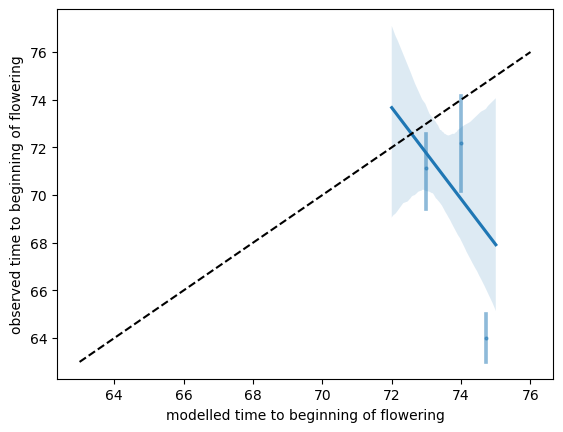

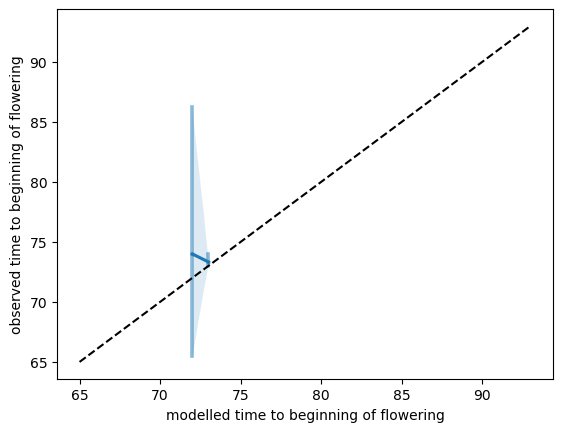

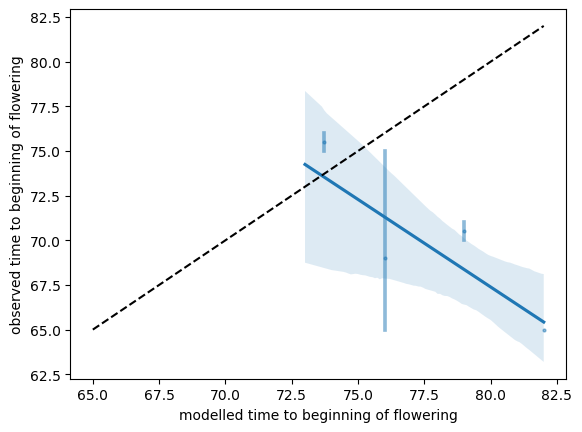

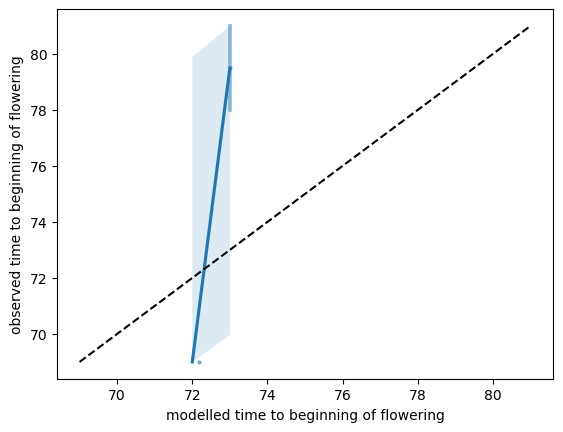

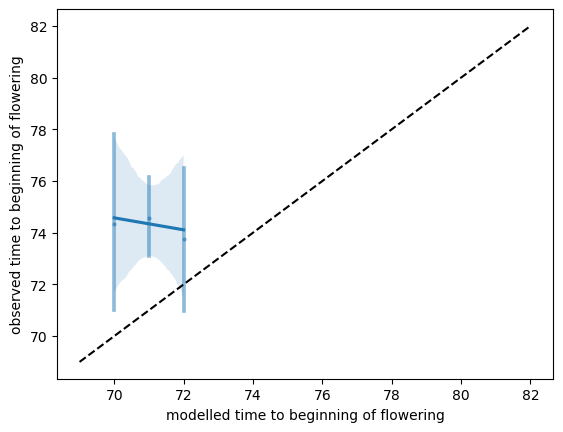

In [ ]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars = KFold_crossval(late_ds_dict['arid high'], 5, index_cols = ['Stations_id'], method = 'trust-constr')

In [106]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'])

Fold 1 123 540 663
Optimization terminated successfully.
         Current function value: 8.678411
         Iterations: 63
         Function evaluations: 150
[ 0.5  8.  28.  39. ] [ 0.31645072  7.05043925 24.55601052 39.32086971] [ 0.18354928  0.94956075  3.44398948 -0.32086971]
RMSE at opt on test set:  10.565706144951383
R^2: 0.31835342188872306
Fold: 1
R2: 0.3183534218887224
Bias: 0
Variance: 64.6054911368786
Fold 2 137 526 663
Optimization terminated successfully.
         Current function value: 9.077926
         Iterations: 65
         Function evaluations: 158
[ 0.5  8.  28.  39. ] [ 0.31426228  7.16370297 24.40623489 39.30390911] [ 0.18573772  0.83629703  3.59376511 -0.30390911]
RMSE at opt on test set:  9.048127604023174
R^2: 0.30870276043452183
Fold: 2
R2: 0.3087027604345217
Bias: 0
Variance: 14.80785744954916
Fold 3 126 537 663
Optimization terminated successfully.
         Current function value: 9.035312
         Iterations: 73
         Function evaluations: 158
[ 0.5  8. 

In [113]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], just_scale = True)

Fold 1 123 540 663
 
 Func-count     x          f(x)          Procedure
    1        1.91601       54.911        initial
    2        3.09399      60.8135        golden
    3        1.18798      45.5828        golden
    4       0.738031      31.3589        golden
    5       0.459948      15.7688        golden
    6       0.288083      31.3865        golden
    7       0.513151      18.8193        parabolic
    8       0.394301      14.9293        golden
    9       0.410067      14.4462        parabolic
   10       0.419781      14.4158        parabolic
   11        0.41637      14.4151        parabolic
   12        0.41788      14.3942        parabolic
   13       0.418062      14.4057        parabolic
   14       0.417277      14.3955        parabolic
   15        0.41765      14.3881        golden
   16       0.417592      14.4046        parabolic
   17       0.417737       14.393        golden
   18       0.417683      14.3897        golden
   19       0.417628      14.3881      

In [118]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], response_type = 'Convolved')

Fold 1 123 540 663
Optimization terminated successfully.
         Current function value: 8.463320
         Iterations: 52
         Function evaluations: 133
[ 0.5  8.  28.  39. ] [ 0.46926925  9.03877877 26.95021292 39.21014219] [ 0.03073075 -1.03877877  1.04978708 -0.21014219]
RMSE at opt on test set:  9.966610925150702
R^2: 0.3934631205765362
Fold: 1
R2: 0.39346312057653565
Bias: 0
Variance: 92.70771691323468
Fold 2 137 526 663
Optimization terminated successfully.
         Current function value: 8.703502
         Iterations: 58
         Function evaluations: 135
[ 0.5  8.  28.  39. ] [ 0.44153149  7.93604348 26.32738382 39.31324157] [ 0.05846851  0.06395652  1.67261618 -0.31324157]
RMSE at opt on test set:  8.590862570663623
R^2: 0.37680934475333916
Fold: 2
R2: 0.3768093447533388
Bias: 0
Variance: 23.082975525976817
Fold 3 126 537 663
Optimization terminated successfully.
         Current function value: 8.680658
         Iterations: 77
         Function evaluations: 169
[ 0.5  8.

In [119]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_TREx_SSA.csv')

In [122]:
step = 0.25
x1s = np.array(params).mean(axis=0)
sd = 8
step = 0.25
table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x1s[1], x1s[2], x1s[3], 3)
table = scipy.ndimage.gaussian_filter(table2, sd/step, mode='constant', cval = 0, axes=0)
def response(meantemp):
    return x1s[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)

In [131]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], response_type = 'Convolved', just_scale = True)

Fold 1 123 540 663
 
 Func-count     x          f(x)          Procedure
    1        1.91601      52.0239        initial
    2        3.09399      59.0203        golden
    3        1.18798      40.7147        golden
    4       0.738031      23.0073        golden
    5       0.459948      12.4394        golden
    6       0.288083      51.1529        golden
    7       0.566166      11.0375        golden
    8       0.535209      9.41079        parabolic
    9       0.520612      9.08203        parabolic
   10       0.510824      9.03881        parabolic
   11       0.512744      9.07755        parabolic
   12       0.491391      9.70691        golden
   13       0.503401      9.21261        golden
   14       0.507988      9.11277        golden
   15       0.509741      9.04833        golden
   16       0.510738       9.0429        parabolic
   17       0.511557      9.04393        golden
   18       0.511138      9.01593        parabolic
   19       0.511298      9.02558        gold

In [132]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD TREx response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_TREx_Sanchez_SSA.csv')

In [133]:
err_df

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD TREx response,SSA,5-fold CV,0.334784,0.0,115.012329,9.240246,10.351927,0.670452,-29.0,-4.05,0.4,5.55,26.8


In [134]:
np.sqrt(115.01)

np.float64(10.724271537032248)

In [127]:
20/(table.max()*x1s[0])

np.float64(61.17286886297495)

In [120]:
np.array(params).mean(axis=0)

array([ 0.45762509,  8.08630901, 26.79581137, 39.1728868 ])

In [121]:
np.sqrt(76.7)

np.float64(8.757853618324527)

In [104]:
np.array(params).mean(axis=0)

array([ 0.3165638 ,  8.42068571, 24.36840505, 39.09078988])

In [108]:
20/0.3165

63.191153238546605

In [109]:
np.sqrt(76.75)

np.float64(8.760707733967616)

In [ ]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'])

In [ ]:
cfs, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds_inputs_SSA, 5, index_cols = ['Stations_id', 'year'], response_type = 'Convolved')

In [ ]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_GDD_SSA.csv')

In [114]:
err_df = make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, 'GDD Wang response', 'SSA', '5-fold CV')
err_df.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\important_results\\NEW_error_df_GDD_SSA_Sanchez.csv')

In [100]:
err_df

,model,region,evaluation method,R2,Bias (obs minus modelled),Variance,RMSE,STD,Corr,Min,LQ,Median,UQ,Max
0,GDD Wang response,SSA,5-fold CV,0.28038,0.0,76.745723,9.659049,7.835517,0.62123,-28.2,-5.5,0.0,5.2,26.4


In [94]:
np.mean(np.array(R2s))

np.float64(0.28038000720759115)

In [10]:
def make_error_df(R2s, Biases, Variances, RMSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, model, region, eval_method):
    error_df = pd.DataFrame({
        'model': [model],
        'region': [region],
        'evaluation method': [eval_method],
        'R2': [np.mean(R2s)],
        'Bias (obs minus modelled)': [np.mean(Biases)],
        'Variance': [np.mean(Variances)],
        'RMSE': [np.mean(RMSEs)],
        'STD': [np.mean(STDs)],
        'Corr': [np.mean(Corrs)],
        'Min': [np.mean(Mins)],
        'LQ': [np.mean(LQs)],
        'Median': [np.mean(Medians)],
        'UQ': [np.mean(UQs)],
        'Max': [np.mean(Maxs)]
    })
    return error_df

In [11]:
#ds_inputs_DE = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5.csv')
ds_inputs_DE1 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_2001_2024_full.csv')
ds_inputs_DE1[[f't2max at day {n}' for n in range(180)]] += -273.15
ds_inputs_DE1[[f't2min at day {n}' for n in range(180)]] += -273.15
ds_inputs_DE2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_90s.csv')
ds_inputs_DE = pd.concat([ds_inputs_DE1, ds_inputs_DE2], axis = 0)
#ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]] = modelling_fctns.Wang_Engel_Temp_response(ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]], 7, 28, 42)
ds_inputs_DE=ds_inputs_DE.rename(columns={'Referenzjahr':'year'})
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.dropna(how='all')
print(len(ds_inputs_DE))
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] < 140]
ds_inputs_DE = ds_inputs_DE.loc[ds_inputs_DE['observed time to beginning of flowering'] > 40]
for vble in ['photoperiod', 'DTF', 'dev stage', 'vpd', 'ssrd', 't2max', 't2min', 'tp']:
    ds_inputs_DE = ds_inputs_DE.drop(columns = [col for col in ds_inputs_DE.columns if vble in col])
ds_inputs_DE_reduced = ds_inputs_DE.sample(frac = 0.2, random_state=1)

27153
27153


In [12]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008.csv')
ds_inputs_SSA=ds_inputs_SSA.rename(columns={'Referenzjahr':'year'})
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]
ds_sites_AEZ2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\African_data\\Lobell2011\\EIL_site_latlon_with_AEZ_filled.csv')
ds_inputs_SSA = ds_inputs_SSA.merge(ds_sites_AEZ2.rename(columns = {'LocationID': 'Stations_id'})[['Stations_id', 'AEZ2']], on='Stations_id', how='left')
ds_inputs_SSA['AEZ'] = ds_inputs_SSA['AEZ2']
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['lat'] > -25]

In [63]:
x_conv = [ 0.30567229, 7, 23.75562448, 39.63485568]#[0.409288, 9.3, 28.3, 39.2]#[0.38440351, 10.4677448, 22.03077464, 39.00469822]#
train_a, test_a = train_test_split(ds_inputs_SSA, test_size=0.2, random_state = 2)
r = run_GDD(x_conv, test_a, 't2m', response_type='Wang', phase_list = ['beginning of flowering'], exclude_unfinished=False, growing_period_length=130, 
                                        thresholds = [20], index_cols = ['Stations_id', 'year'])

201 133 133


In [58]:
RMSE = run_GDD_and_get_RMSE(x_conv, test_a, 't2m', response_type='Wang', phase_list = ['beginning of flowering'], growing_period_length=130, 
                                        thresholds = [20])

133 133 133


In [59]:
1 - (RMSE**2/(test_a[f'observed time to beginning of flowering'].var()*((len(test_a) - 1)/len(test_a))))

np.float64(0.29745948949505163)

In [60]:
len(test_a)

133

In [61]:
len(r)

133

In [62]:
r2_score(r['observed time to beginning of flowering'], r['modelled time to beginning of flowering'])

0.29745948949505163

In [30]:
#def run_GDD(x, ds, driver_variable, latlon_proj = True, response_type = 'Trapezoid', 
#                             phase_list = ['beginning of flowering'], exclude_unfinished = False,
#                             growing_period_length = 300, thresholds = [100], 
#                             title_extra='', method='scatter', savename = False, plot=False, col='blue',
#                             index_cols = ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year']): 
#    #Change index_cols to ['year', 'Stations_id'] if using DE dataset
#    len_index_cols = len(index_cols)
#    if response_type == 'Trapezoid':
#        def response(meantemp):
#            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
#            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], 0.2, 3)#x[3], x[4])
#    elif response_type == 'Wang':
#        def response(meantemp):
#            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
#            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
#    elif response_type == 'Convolved':
#        table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), 10, 3)#, x[4], x[5])#x[2]
#        def response(meantemp):
#            return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
#    elif response_type == 'Convolved_vary_spread':
#        table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
#        def response(meantemp):
#            return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
#    elif response_type == 'multi_phase':
#        def response(meantemp):
#            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
#            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
#        responses = [lambda meantemp: x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3]),
#                     lambda meantemp: x[4]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[5], x[6], x[7])]
#    driver_columns = [f'{driver_variable} at day {day}' for day in range(growing_period_length)]
#    ds_for_model = ds[driver_columns + index_cols].copy()
#    #ds_for_model.loc[:, driver_columns] = ds_for_model.loc[:, driver_columns]#.round(decimals = 10).astype(np.float64)
#    if response_type == 'multi_phase':
#        t_dev = np.zeros(len(ds_for_model))
#        for i, colm in enumerate(driver_columns):
#            resp = modelling_fctns.phase_dependent_response2(ds_for_model.loc[:, colm], t_dev, responses, thresholds)
#            #resp2 = response(ds_for_model.loc[:, colm])
#            #if np.any(resp != resp2):
#            #    print(resp, resp2)
#            #print(resp)
#            t_dev += resp
#            ds_for_model.loc[:, colm] = t_dev
#    else:
#        ds_for_model.loc[:, driver_columns] = response(ds_for_model[driver_columns]).cumsum(axis=1)
#    model_dev_time_series = ds_for_model.values.T
#    column_names = [np.array([f'modelled time to {phase}' for phase in phase_list]+ index_cols)]
#    thresholds_for_phase = thresholds[-1:]
#    #print(thresholds_for_phase, model_dev_time_series.shape[1])
#    phase_dates_array = np.zeros((len(thresholds_for_phase), model_dev_time_series.shape[1]))#
#    for obs_index in range(model_dev_time_series.shape[1]):
#        #print(model_dev_time_series[:-2, obs_index])
#        #print(model_dev_time_series[:-len_index_cols, obs_index])#.astype(np.float64))
#        phase_dates_array[:, obs_index] = np.digitize(thresholds_for_phase, model_dev_time_series[:-len_index_cols, obs_index].astype(np.float64))    
#    #print(phase_dates_array)
#    phase_dates_array = np.concatenate([phase_dates_array, *[[model_dev_time_series[-(k + 1)]] for k in reversed(range(len_index_cols))]], axis=0)
#    #print(column_names)
#    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names[0])
#    #print(ds.columns.to_list(), phase_dates_array.columns.to_list())
#    comparison_array = ds.T.drop_duplicates().T.merge(phase_dates_array, how='left', on=index_cols).dropna(how='all')
#    if plot:
#        plot_from_comparison_array(comparison_array, title_extra=title_extra, method=method, savename=savename, 
#                                  phase_list=phase_list, exclude_unfinished=exclude_unfinished, growing_period_length=growing_period_length,
#                                  col=col)
#    return comparison_array

In [83]:
def run_GDD_and_get_RMSE(x, ds, driver_variable, latlon_proj = True, 
                         response_type = 'Trapezoid', phase_list = ['beginning of flowering'], 
                         new_unfinished_penalisation=False,
                         growing_period_length = 300, thresholds = [100]):
    comparison_array = run_GDD(x, ds, driver_variable, latlon_proj=latlon_proj,
                               response_type=response_type, phase_list=phase_list,
                               growing_period_length=growing_period_length, thresholds=thresholds)
    unfinished_penalty=0
    if new_unfinished_penalisation:
        unfinished_penalty = max((comparison_array[f'modelled time to {phase_list[0]}'] >growing_period_length - 3).sum() - 0.03*comparison_array.shape[0], 0)
        comparison_array = comparison_array.where(comparison_array[f'modelled time to {phase_list[0]}'] < growing_period_length).dropna()
    def RMSE(residuals):
        if len(residuals) == 0:
            return 0
        else:
            return np.sqrt(np.mean(residuals**2))
    phase = phase_list[0]
    residuals = (comparison_array[f'observed time to {phase}'] - comparison_array[f'modelled time to {phase}']).values # np.concatenate([(comparison_array[f'observed time to {phase}'].dt.days - comparison_array[f'modelled time to {phase}']).values for phase in phase_list])
    return RMSE(residuals) + unfinished_penalty#, comparison_array


In [13]:
def cols_in_other(df1, df2, compare_cols):
    index1 = pd.MultiIndex.from_arrays([df1[col] for col in compare_cols])
    index2 = pd.MultiIndex.from_arrays([df2[col] for col in compare_cols])
    return index1.isin(index2)

In [14]:
def split_ds_by_AEZ2(ds):
    ds_arid_low = ds.loc[ds['AEZ'].isin([1, 26, 29])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([2, 3])].groupby(['Stations_id', 'year']).head(2)
    ds_arid_high = ds.loc[ds['AEZ'].isin([4, 10])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_high = ds.loc[ds['AEZ'].isin([5, 11, 14])].groupby(['Stations_id', 'year']).head(2)
    ds_city = ds.loc[ds['AEZ'].isin([32])].groupby(['Stations_id', 'year']).head(2)
    print(f'\nnum arid low: {len(ds_arid_low)}',
        f'\nnum city: {len(ds_city)}',
        f'\nnum arid high: {len(ds_arid_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum humid high: {len(ds_humid_high)}')
    ds_dict = {'arid low': ds_arid_low,
               'city': ds_city,
               'arid high': ds_arid_high,
               'humid low': ds_humid_low,
               'humid high': ds_humid_high}
    return ds_dict

In [15]:
def split_ds_by_AEZ4(ds):
    ds_arid_low = ds.loc[ds['AEZ'].isin([1, 26, 29])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([2, 3])].groupby(['Stations_id', 'year']).head(2)
    ds_high = ds.loc[ds['AEZ'].isin([4, 5])].groupby(['Stations_id', 'year']).head(2)
    ds_cool = ds.loc[ds['AEZ'].isin([10, 11, 14])].groupby(['Stations_id', 'year']).head(2)
    ds_city = ds.loc[ds['AEZ'].isin([32])].groupby(['Stations_id', 'year']).head(2)
    print(f'\nnum arid low: {len(ds_arid_low)}',
        f'\nnum city: {len(ds_city)}',
        f'\nnum high: {len(ds_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum cool: {len(ds_cool)}')
    ds_dict = {'arid low': ds_arid_low,
               'city': ds_city,
               'high': ds_high,
               'humid low': ds_humid_low,
               'cool': ds_cool}
    return ds_dict

In [16]:
def split_ds_by_AEZ5(ds):
    ds_semiarid_low = ds.loc[ds['AEZ'].isin([1])].groupby(['Stations_id', 'year']).head(2)
    ds_arid_low = ds.loc[ds['AEZ'].isin([26, 29])].groupby(['Stations_id', 'year']).head(2)
    ds_subhumid_low = ds.loc[ds['AEZ'].isin([2])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_low = ds.loc[ds['AEZ'].isin([3])].groupby(['Stations_id', 'year']).head(2)
    ds_arid_high = ds.loc[ds['AEZ'].isin([4])].groupby(['Stations_id', 'year']).head(2)
    ds_humid_high = ds.loc[ds['AEZ'].isin([5])].groupby(['Stations_id', 'year']).head(2)
    ds_cool = ds.loc[ds['AEZ'].isin([10, 11, 14])].groupby(['Stations_id', 'year']).head(2)
    print(#f'\nnum cool: {len(ds_cool)}',
        f'\nnum semiarid low: {len(ds_semiarid_low)}',
        f'\nnum arid high: {len(ds_arid_high)}',
        f'\nnum humid low: {len(ds_humid_low)}',
        f'\nnum subhumid low: {len(ds_subhumid_low)}',
        f'\nnum subhumid high: {len(ds_humid_high)}')
    ds_dict = {#'cool': ds_cool,
               'semiarid low': ds_semiarid_low,
               'arid high': ds_arid_high,
               'humid low': ds_humid_low,
               'subhumid low': ds_subhumid_low,
               'humid high': ds_humid_high}
    return ds_dict

In [39]:
def k_fold_crossval_regions(ds_dict, index_cols = ['Stations_id', 'year', 'Management', 'vargroup'], 
                            response_type = 'Wang', plot_profiles=False, just_scale = False,
                            method='Nelder-Mead', plot_corrs = False):
    SSE_all_reg = []
    length_all_reg = []
    obsvars_all_reg = []
    comparison_frames = []
    for region in ds_dict.keys():
        #get data for specific region
        ds = ds_dict[region]
        if len(ds) < 10:
            continue
        #convert to pytorch format
        cf, R2s, Biases, Variances, RMSEs, SSEs, STDs, Corrs, Mins, LQs, Medians, UQs, Maxs, lengths, obsvars, params = KFold_crossval(ds, 5, 
                                                                                                                               method = method,
                                                                                                                               index_cols = index_cols,
                                                                                                                               response_type = response_type,
                                                                                                                               just_scale=just_scale,
                                                                                                                               plot_profiles=plot_profiles,
                                                                                                                               plot_corrs=plot_corrs)
        print(region, R2s)
        #Store sum of squared errors, variance of obs and length of folds for evaluation
        print(1 - (np.array(SSEs)/((np.array(lengths) - 1)*np.array(obsvars))))
        SSE_all_reg.append(SSEs)
        length_all_reg.append(lengths)
        obsvars_all_reg.append(obsvars)
        comparison_frames.append(cf)
    results_dict = {'SSEs': SSE_all_reg,
                    'observed variances': obsvars_all_reg,
                    'fold lengths': length_all_reg,
                    'comparison_frames': comparison_frames}
    return results_dict

In [18]:
def skill_score_all_reg(score_dict):
    SSE_all_reg = np.array(score_dict['SSEs'])
    obsvars_all_reg = np.nan_to_num(np.array(score_dict['observed variances']))
    length_all_reg = np.array(score_dict['fold lengths'])
    MSE_all_reg = SSE_all_reg.sum(axis=0)/length_all_reg.sum(axis = 0)
    R2_all_reg = 1 - (SSE_all_reg.sum(axis=0)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=0))
    R2_all_reg_split = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))
    #R2_pooled = 1 - (SSE_all_reg.sum(axis=1)/((length_all_reg - 1)*obsvars_all_reg).sum(axis=1))
    R2_pooled = []
    for cf in score_dict['comparison_frames']:
        R2_pooled.append(r2_score(cf['observed time to beginning of flowering'], cf['modelled time to beginning of flowering']))
    R2_pooled = np.array(R2_pooled)
    #print(R2_all_reg, ((length_all_reg - 1)*obsvars_all_reg).sum(axis=0))
    return R2_all_reg, R2_all_reg_split, R2_pooled

def make_df_from_score_dict(score_dict, TL_method = 'NA', variety = 'NA'):
    R2s, R2s_split, R2s_pooled = skill_score_all_reg(score_dict)
    df = pd.DataFrame()
    df['R2 score'] = R2s_split.mean(axis=1)
    df_pooled = pd.DataFrame()
    df_pooled['R2 score'] = R2s_pooled
    df['Variety'] = variety
    df_pooled['Variety'] = variety
    df_full_model = pd.DataFrame()
    df_full_model['Variety'] = [variety]
    df_full_model['R2 score'] = [R2s.mean()]
    return df, df_pooled, df_full_model

In [19]:
ds_inputs_SSA = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\SSA_ML_ERA5_1999_2008_with_varieties_fixed_vpd.csv')
ds_inputs_SSA=ds_inputs_SSA.rename(columns={'Referenzjahr':'year'})
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['observed time to beginning of flowering'] < 105]
ds_sites_AEZ2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\African_data\\Lobell2011\\EIL_site_latlon_with_AEZ_filled.csv')
ds_inputs_SSA = ds_inputs_SSA.merge(ds_sites_AEZ2.rename(columns = {'LocationID': 'Stations_id'})[['Stations_id', 'AEZ2']], on='Stations_id', how='left')
ds_inputs_SSA['AEZ'] = ds_inputs_SSA['AEZ2']
ds_inputs_SSA = ds_inputs_SSA.loc[ds_inputs_SSA['lat'] > -25]

In [20]:
#ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
#ds_SSA_early = ds_SSA_early.loc[(ds_SSA_early['Management'] == 'Optimal')|(ds_SSA_early['Management'] == 'Low pH')|(ds_SSA_early['Management'] == 'Low N')].groupby(['Stations_id', 'year']).first().reset_index()
#early_ds_dict = split_ds_by_AEZ2(ds_SSA_early)
ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
ds_SSA_early = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'EPOP')|(ds_inputs_SSA['vargroup'] == 'EIHY')].reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
#ds_SSA_early.loc[:,'Stations_id'] = ds_SSA_early['Stations_id'].astype(str) + ds_SSA_early['Management'].astype(str) + ds_SSA_early['vargroup'].astype(str)
early_ds_dict = split_ds_by_AEZ5(ds_SSA_early)


num semiarid low: 120 
num arid high: 59 
num humid low: 26 
num subhumid low: 67 
num subhumid high: 45


In [21]:
#ds_SSA_early[['Stations_id', 'year']].drop_duplicates()

In [22]:
#ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].groupby(['Stations_id', 'year', 'Management']).first().reset_index().drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
#ds_SSA_late = ds_SSA_late.loc[(ds_SSA_late['Management'] == 'Optimal')|(ds_SSA_late['Management'] == 'Low pH')|(ds_SSA_late['Management'] == 'Low N')].groupby(['Stations_id', 'year']).first().reset_index()
#late_ds_dict = split_ds_by_AEZ2(ds_SSA_late)
ds_SSA_late = ds_inputs_SSA.loc[(ds_inputs_SSA['vargroup'] == 'ILPO')|(ds_inputs_SSA['vargroup'] == 'ILHY')].reset_index().drop(columns=['Unnamed: 0'])#, 'Unnamed: 0.1'])
#ds_SSA_late.loc[:,'Stations_id'] = ds_SSA_late['Stations_id'].astype(str) + ds_SSA_late['Management'].astype(str) + ds_SSA_late['vargroup'].astype(str)
late_ds_dict = split_ds_by_AEZ5(ds_SSA_late)


num semiarid low: 101 
num arid high: 50 
num humid low: 17 
num subhumid low: 68 
num subhumid high: 46


Fold 1 25 95 120
Optimization terminated successfully.
         Current function value: 8.937067
         Iterations: 46
         Function evaluations: 123
[ 0.5  8.  23.  39. ] [ 0.36669091  8.68913763 27.20417911 39.0335065 ] [ 0.13330909 -0.68913763 -4.20417911 -0.0335065 ]
RMSE at opt on test set:  6.690847618984094
R^2: 0.8209485674248352
25
Fold: 1
R2: 0.8049799700510668
Bias: 0
Variance: 136.15666666666667
Fold 2 27 93 120
Optimization terminated successfully.
         Current function value: 8.705003
         Iterations: 57
         Function evaluations: 141
[ 0.5  8.  23.  39. ] [ 0.3566918   8.31261177 26.73873244 39.07274365] [ 0.1433082  -0.31261177 -3.73873244 -0.07274365]
RMSE at opt on test set:  7.683802205062973
R^2: 0.6514918615219367
27
Fold: 2
R2: 0.6746882591093117
Bias: 0
Variance: 68.27635327635326
Fold 3 23 97 120
Optimization terminated successfully.
         Current function value: 8.478928
         Iterations: 44
         Function evaluations: 122
[ 0.5  8.  

C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_13612\1251156230.py:84: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax=plt.subplots()


Fold 2 9 36 45
Optimization terminated successfully.
         Current function value: 6.685806
         Iterations: 56
         Function evaluations: 145
[ 0.5  8.  23.  39. ] [ 0.2740933  10.85761023 19.50495926 39.06372858] [ 0.2259067  -2.85761023  3.49504074 -0.06372858]
RMSE at opt on test set:  8.35463942968217
R^2: 0.20770739910313873
9
Fold: 2
R2: 0.25714686098654715
Bias: 0
Variance: 52.44444444444444
Fold 3 7 38 45
Optimization terminated successfully.
         Current function value: 6.578201
         Iterations: 79
         Function evaluations: 182
[ 0.5  8.  23.  39. ] [ 0.27463047  9.86530388 20.09556504 39.32462743] [ 0.22536953 -1.86530388  2.90443496 -0.32462743]
RMSE at opt on test set:  9.27960727138337
R^2: -0.09425426463808217
7
Fold: 3
R2: -0.2090248962655603
Bias: 0
Variance: 1.5714285714285712
Fold 4 11 34 45
Optimization terminated successfully.
         Current function value: 7.234178
         Iterations: 76
         Function evaluations: 181
[ 0.5  8.  23. 

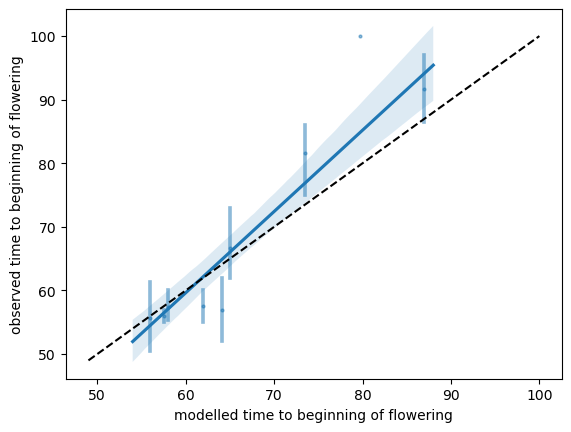

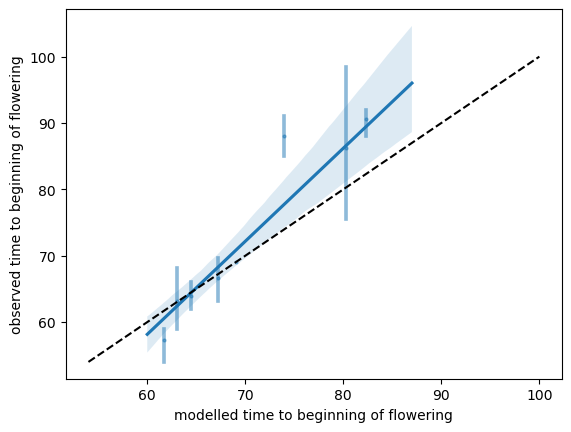

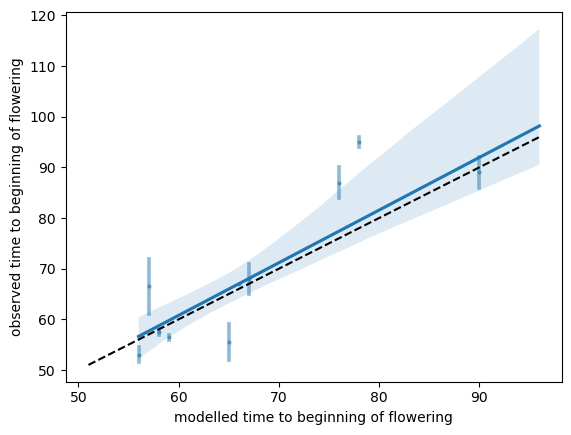

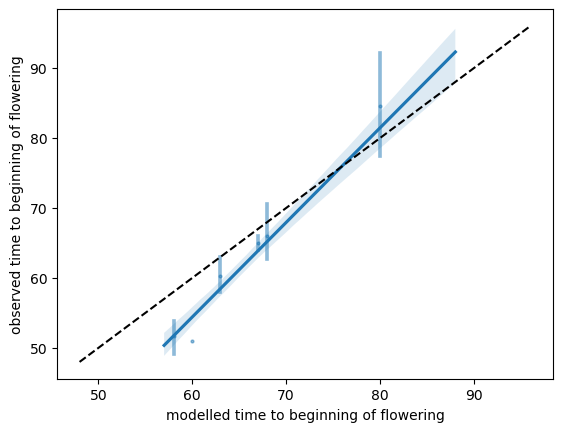

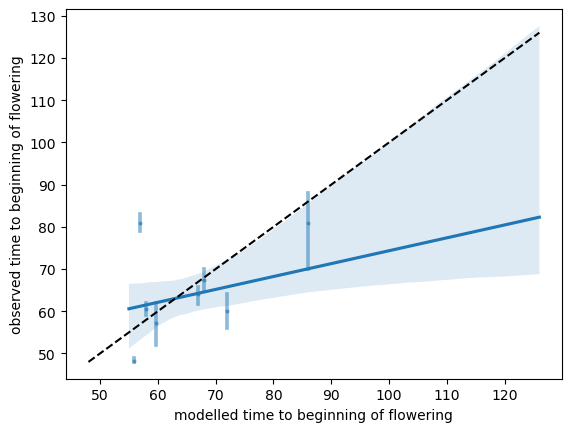

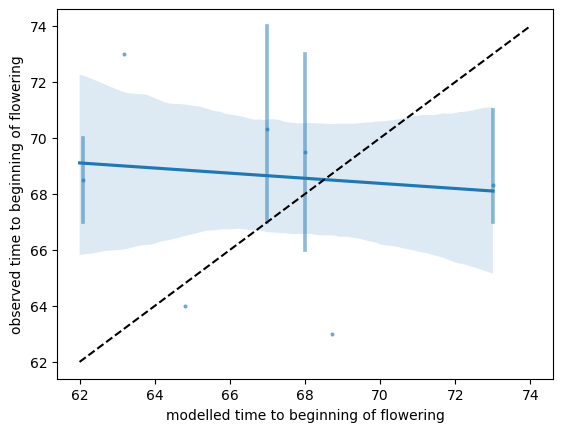

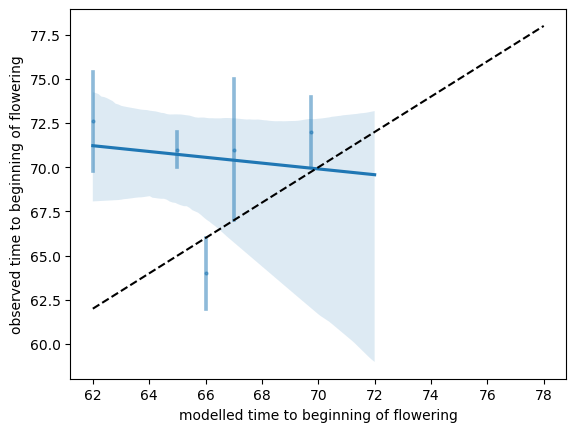

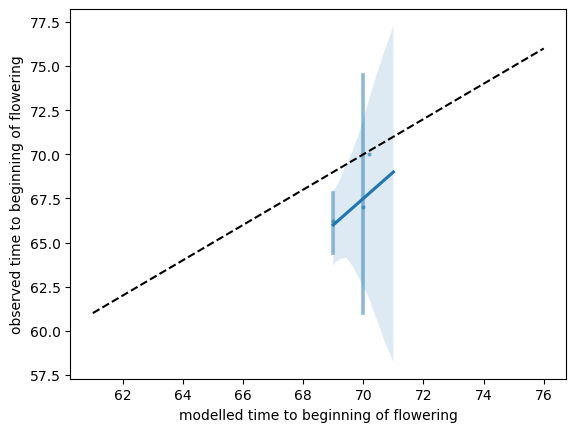

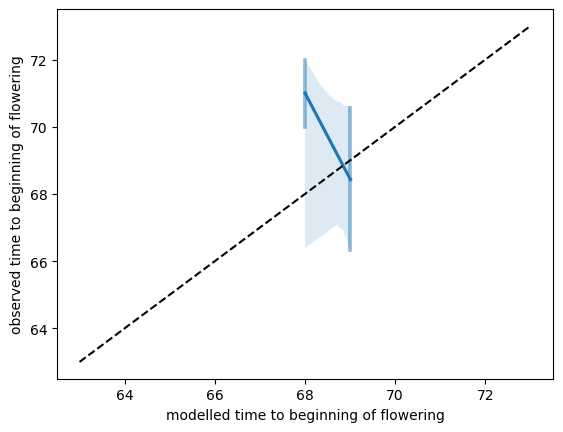

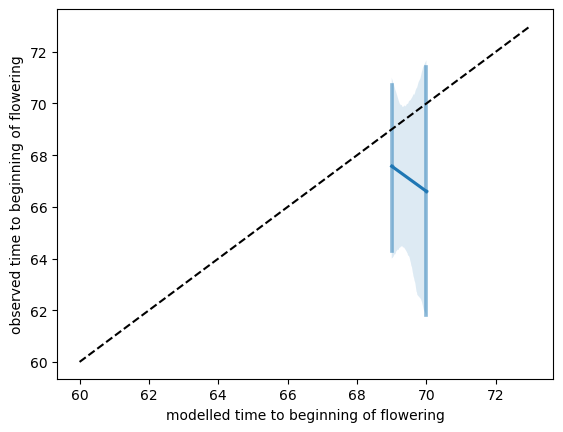

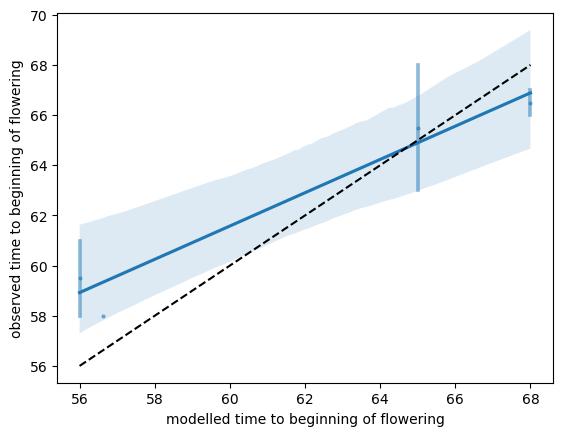

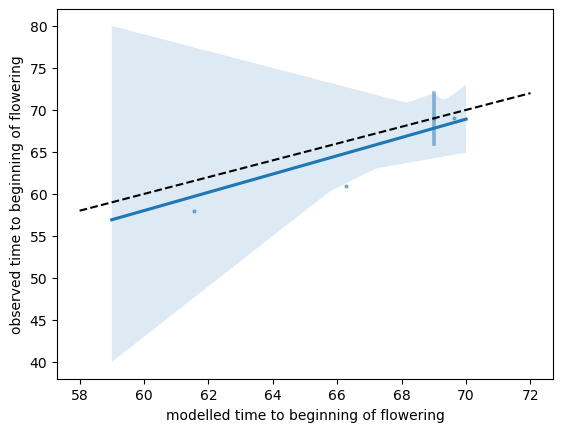

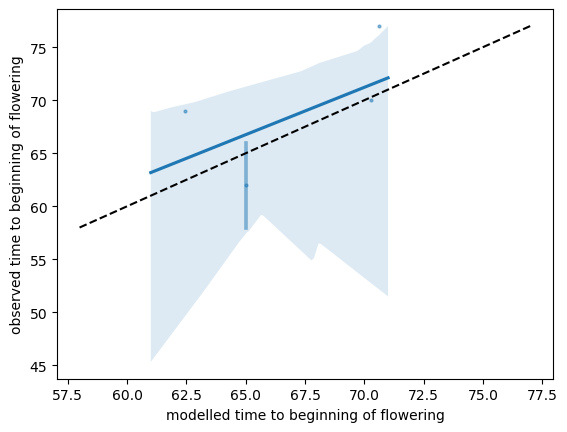

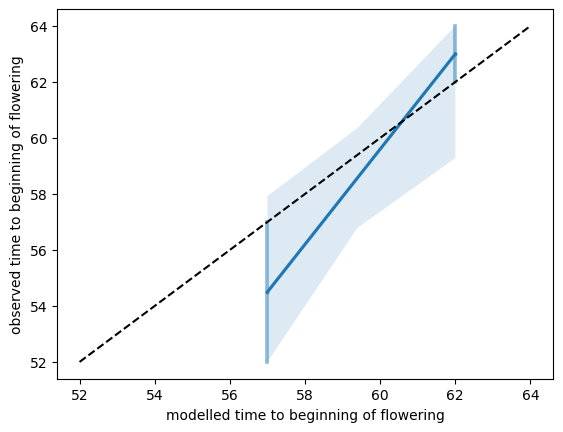

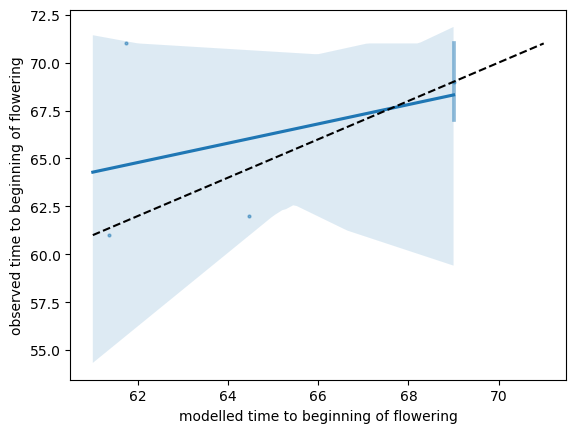

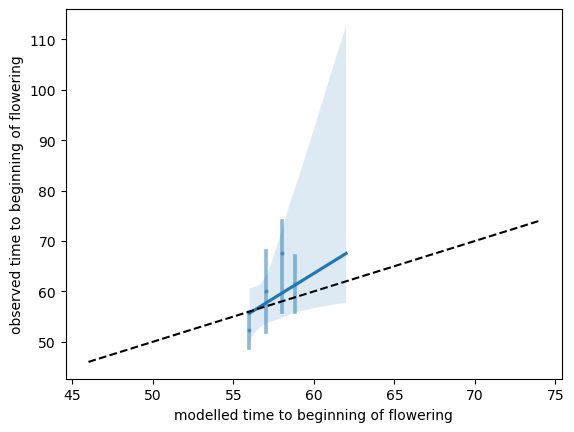

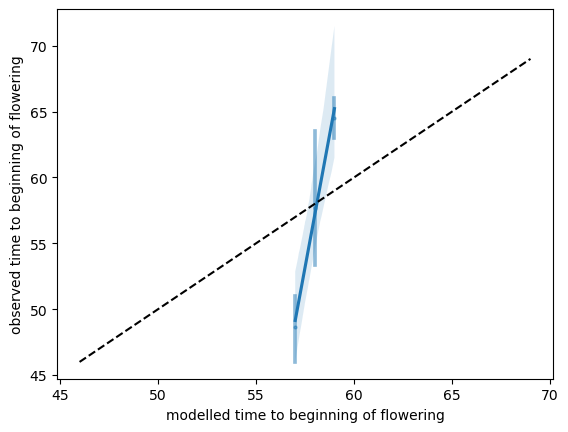

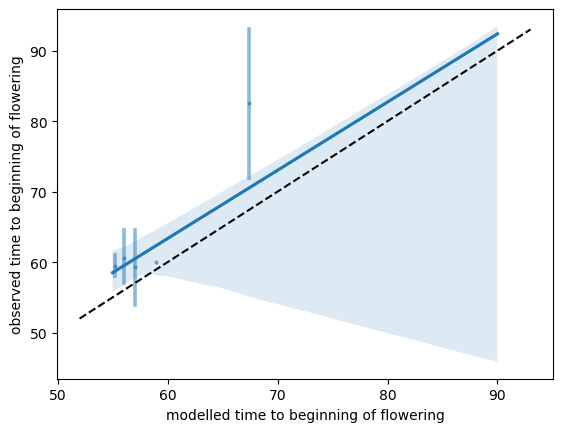

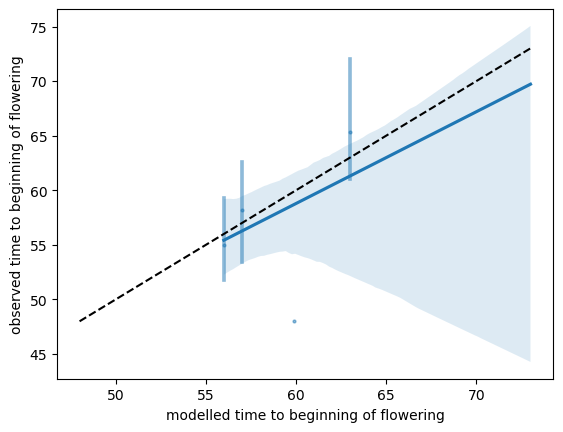

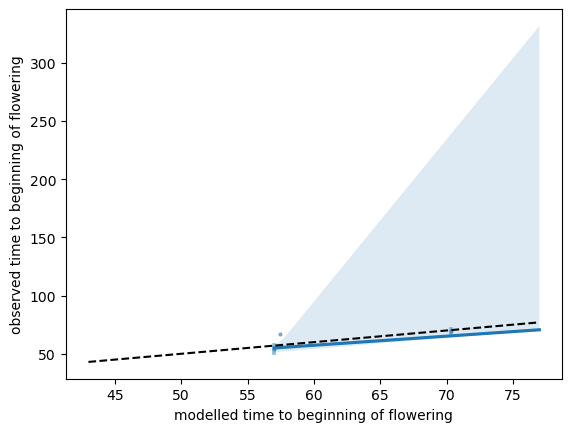

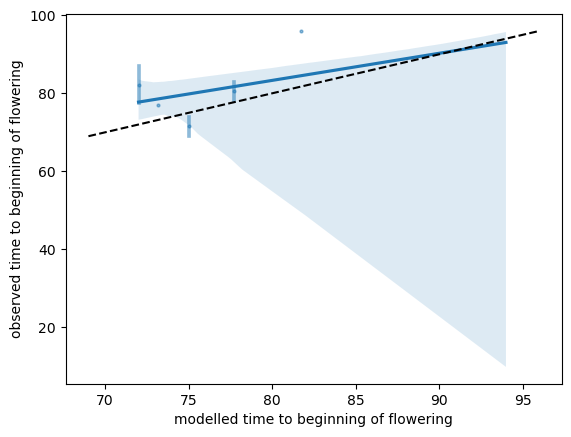

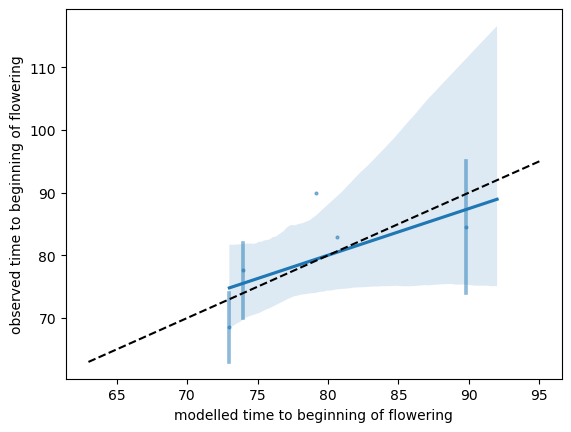

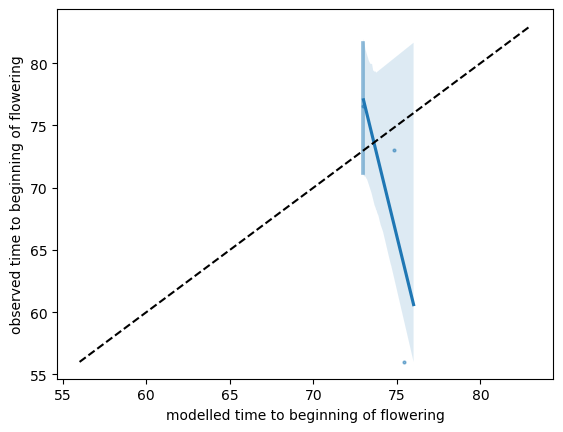

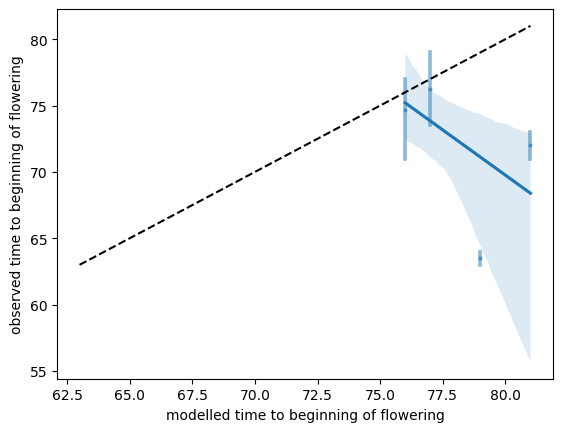

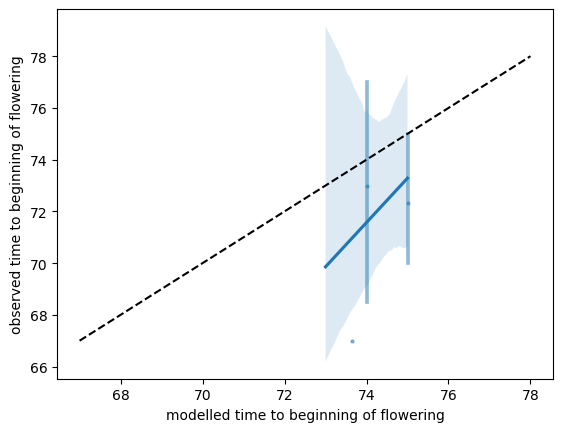

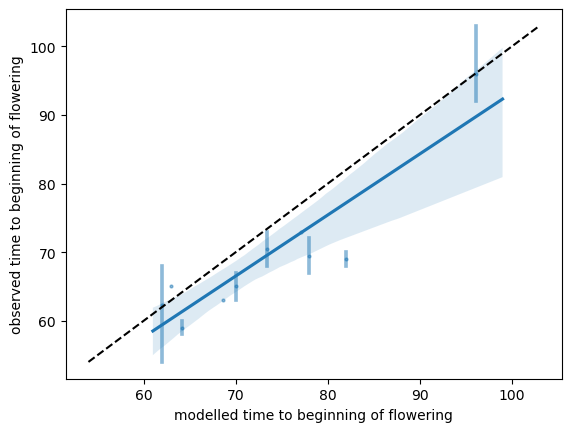

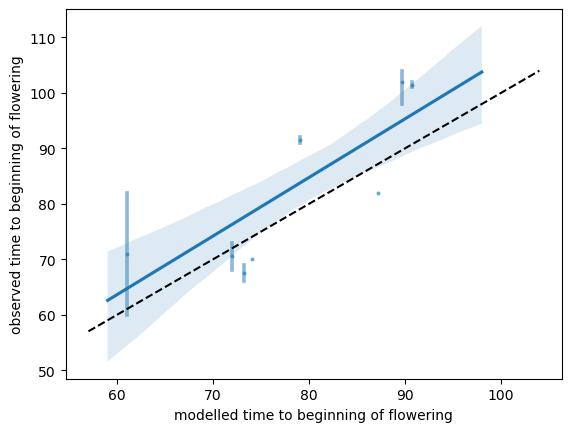

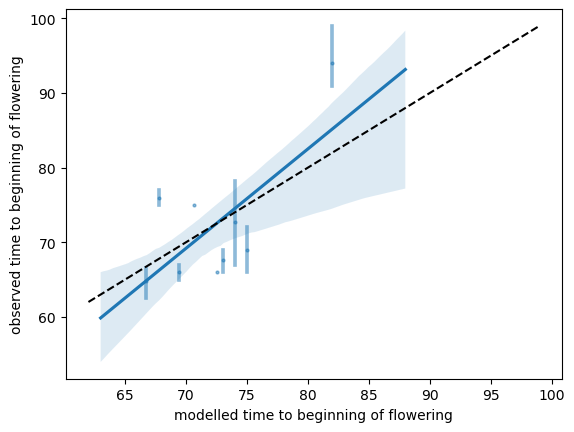

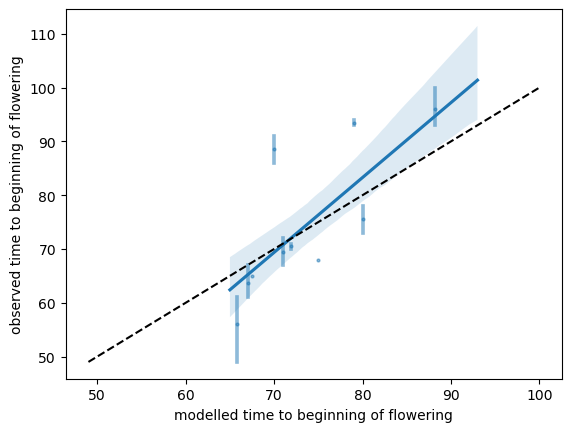

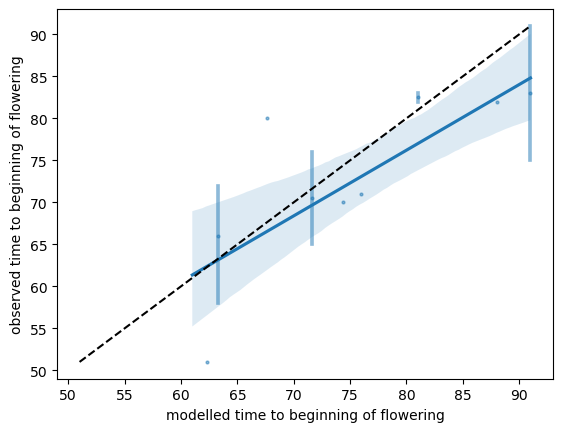

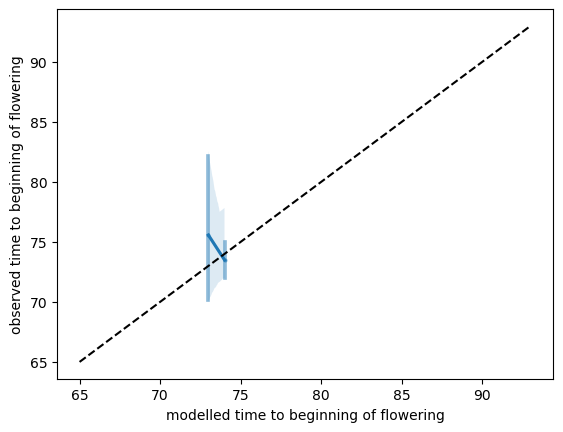

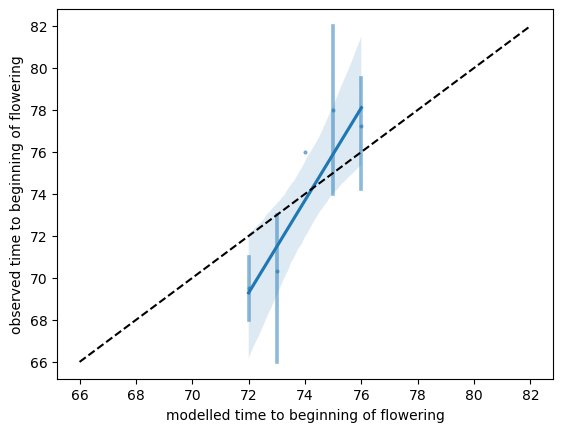

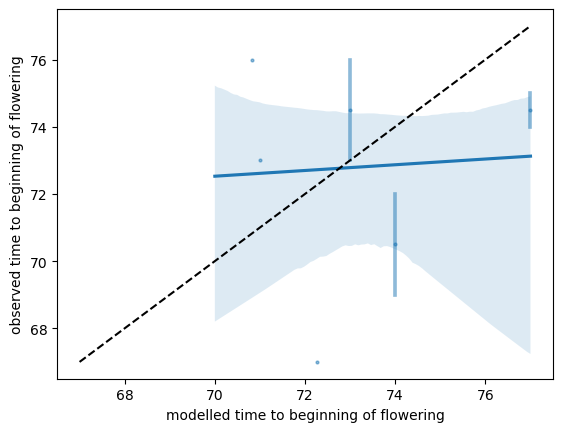

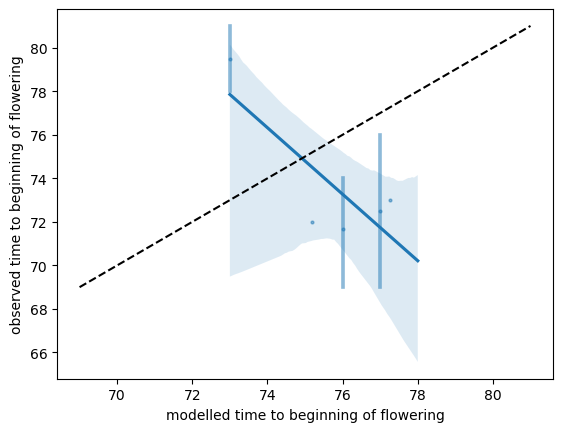

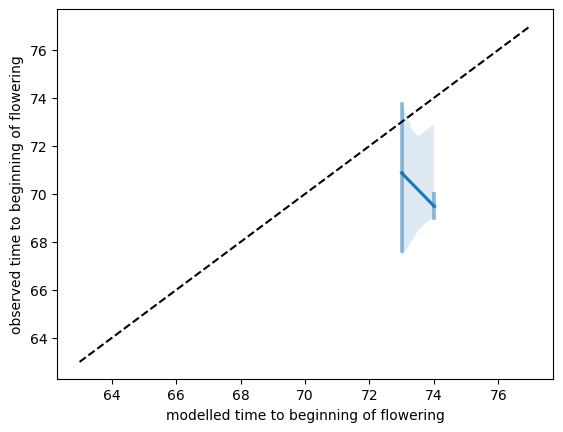

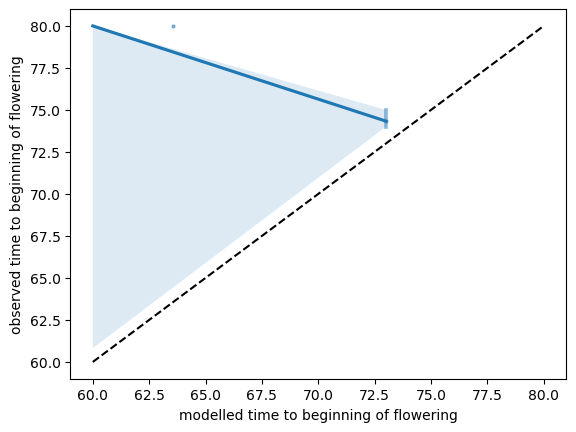

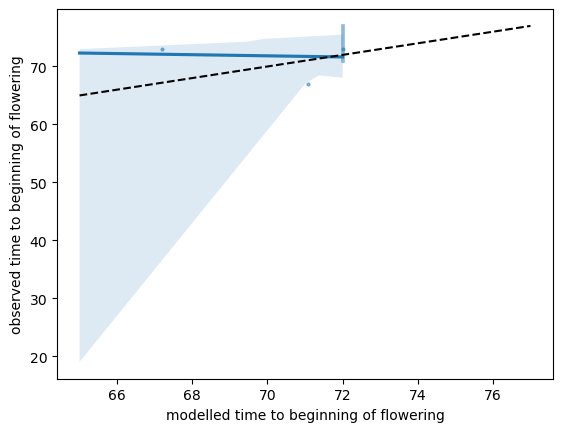

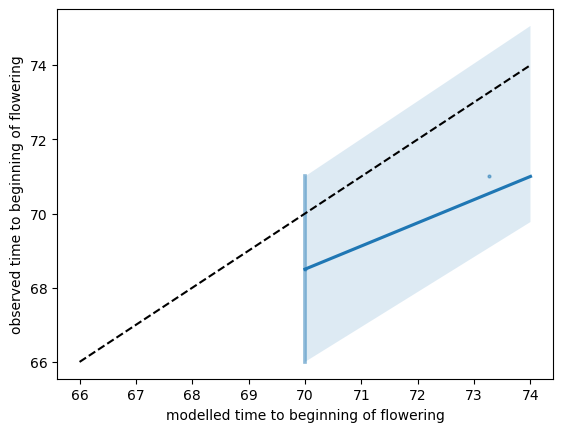

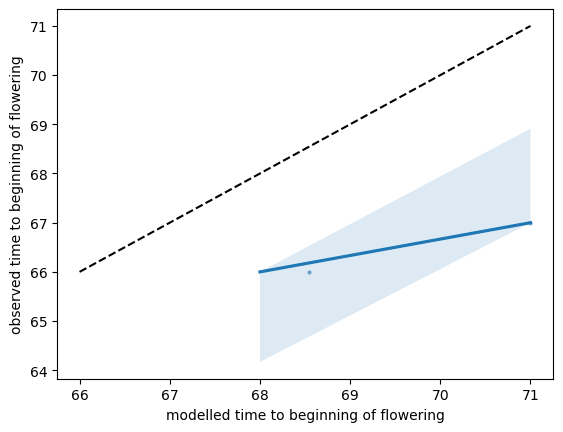

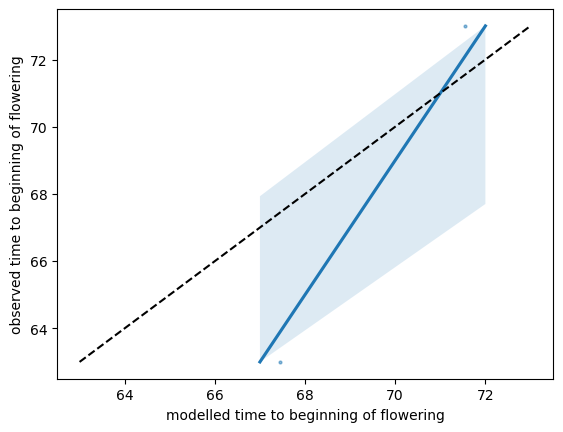

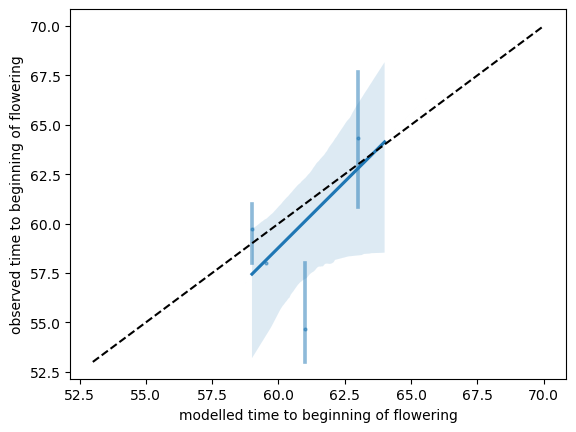

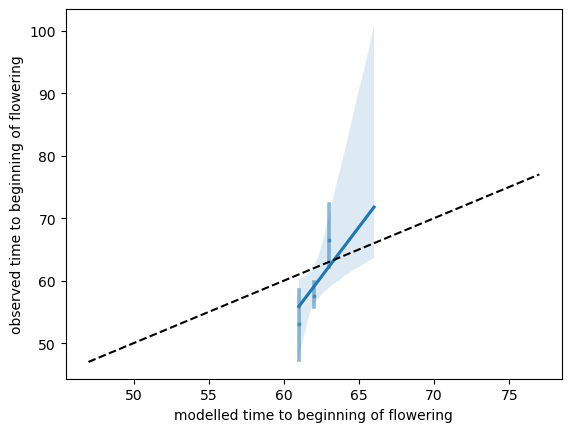

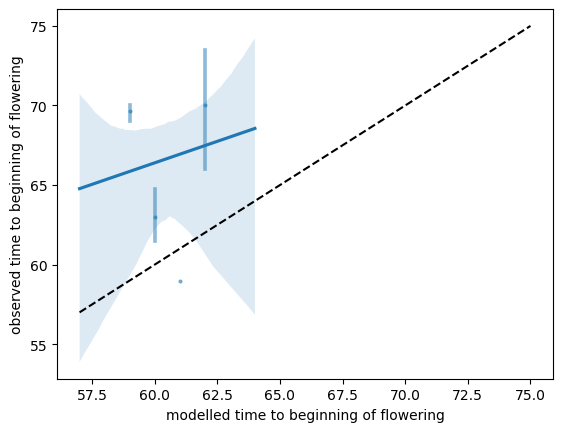

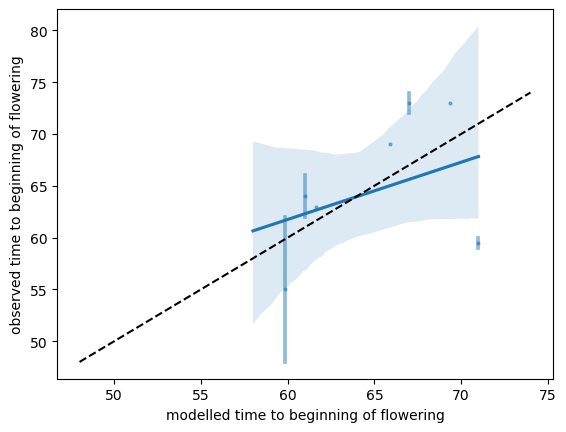

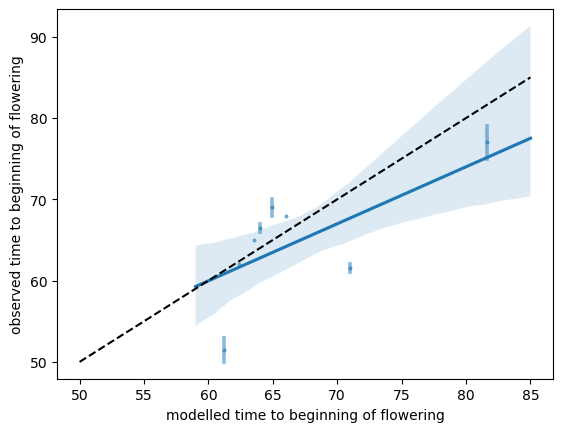

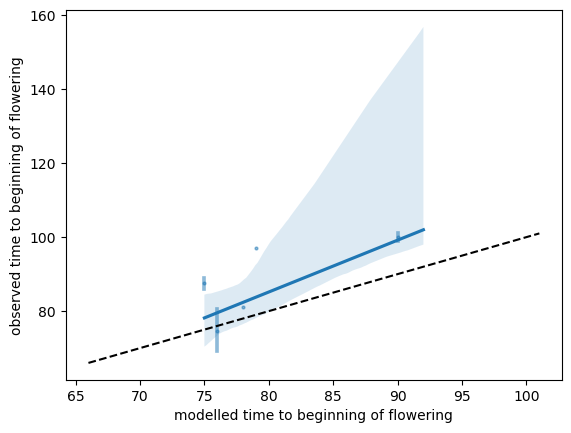

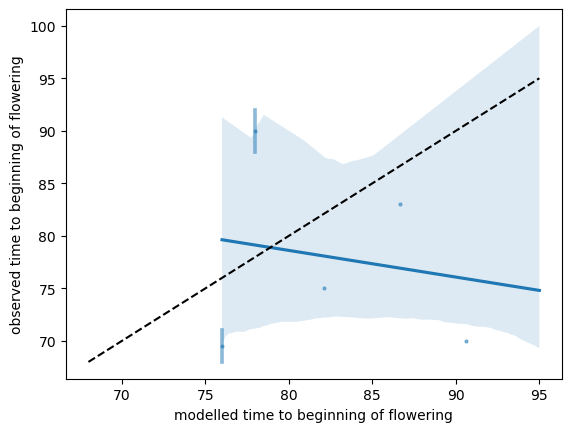

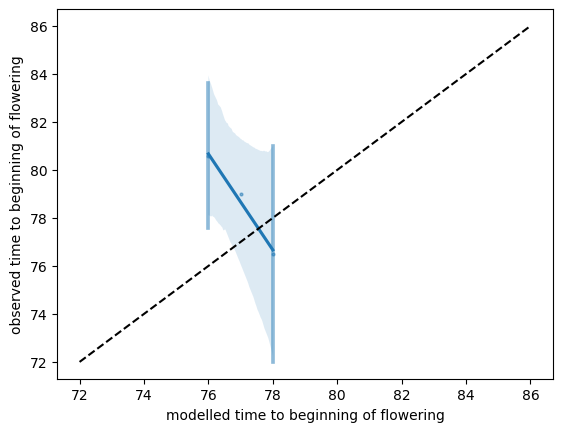

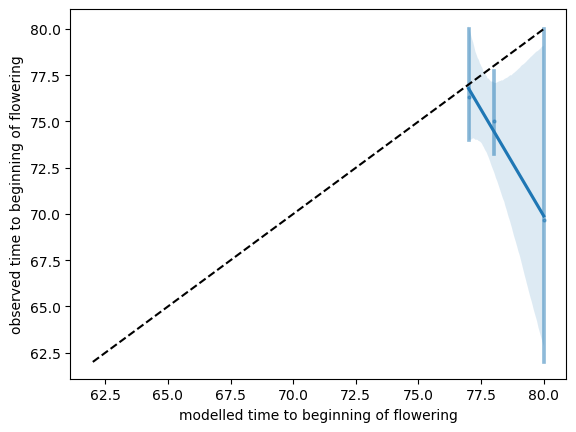

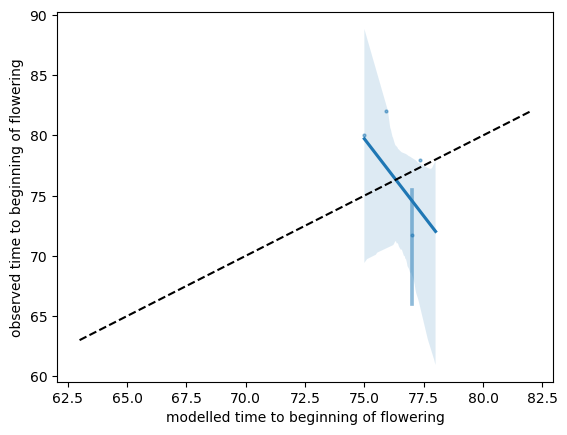

In [51]:
results_dict_early = k_fold_crossval_regions(early_ds_dict, index_cols = ['Stations_id', 'year'])
results_dict_late = k_fold_crossval_regions(late_ds_dict, index_cols = ['Stations_id', 'year'])

In [ ]:
for ind, score_dict in enumerate([results_dict_early, results_dict_late]):
    variety = ['early', 'late'][ind]
    TL_method = ['first', 'first'][ind]
    df, df_pooled, df_full_model = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    if ind == 1:
        df['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low'])
        df_pooled['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low'])
    else:
        df['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
        df_pooled['region'] = ['np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])']#(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
    df_full_model['region'] = 'all combined'
    df = pd.concat((df, df_full_model))
    df_pooled = pd.concat((df_pooled, df_full_model))
    if ind == 0:
        df_full = df
        df_pooled_full = df_pooled
    else:
        df_full = pd.concat([df_full, df])
        df_pooled_full = pd.concat([df_pooled_full, df_pooled])



In [53]:
df_pooled_full

,R2 score,Variety,region
0,0.585387,early,semiarid low
1,-0.775053,early,arid high
2,0.555371,early,humid low
3,0.387546,early,subhumid low
4,0.066782,early,humid high
0,0.355945,early,all combined
0,0.597803,late,semiarid low
1,-0.061429,late,arid high
2,-0.844575,late,humid low
3,0.121004,late,subhumid low


In [50]:
df_pooled_full

,R2 score,Variety,region
0,0.584879,early,semiarid low
1,-1.081772,early,arid high
2,0.520521,early,humid low
3,0.404193,early,subhumid low
4,0.032295,early,humid high
0,0.234760,early,all combined
0,0.532444,late,semiarid low
1,0.017133,late,arid high
2,-0.791606,late,humid low
3,0.072727,late,subhumid low


In [81]:
df_pooled_full

,R2 score,Variety,region
0,0.584879,early,semiarid low
1,-0.324759,early,arid high
2,0.520521,early,humid low
3,0.423938,early,subhumid low
4,0.106244,early,humid high
0,0.241425,early,all combined
0,0.532444,late,semiarid low
1,-0.461470,late,arid high
2,-0.791606,late,humid low
3,0.072727,late,subhumid low


In [56]:
results_dict_late['fold lengths']

[[18, 24, 16, 18, 25],
 [15, 7, 9, 3, 22],
 [3, 7, 4, 1, 2],
 [16, 5, 9, 18, 20],
 [13, 14, 7, 4, 11]]

In [82]:
results_dict_early['fold lengths']

[[29, 25, 27, 19, 20],
 [31, 5, 9, 14, 7],
 [4, 4, 10, 3, 5],
 [7, 14, 16, 10, 21],
 [6, 17, 12, 11, 3]]

In [54]:
df_pooled_full['Model'] = 'GDD'
df_pooled_full.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\split_varieties_pooled_score_GDD_new_split.csv')

In [39]:
df_pooled_full

,R2 score,Variety,region
0,0.584879,early,semiarid low
1,-0.324759,early,arid high
2,0.520521,early,humid low
3,0.423938,early,subhumid low
4,0.106244,early,humid high
0,-2.542895,early,all combined
0,0.532444,late,semiarid low
1,-0.461470,late,arid high
2,-0.791606,late,humid low
3,0.072727,late,subhumid low


In [ ]:
#df_full

,R2 score,Variety,region
0,-3.027298,early,semiarid low
1,-11.462250,early,arid high
2,-inf,early,humid low
3,-2.418962,early,subhumid low
4,-2.909958,early,humid high
0,-2.542895,early,all combined
0,-7.789157,late,semiarid low
1,-17.023871,late,arid high
2,NaN,late,humid low
3,-6.556416,late,subhumid low


Fold 1 38 183 221
Optimization terminated successfully.
         Current function value: 8.716257
         Iterations: 45
         Function evaluations: 122
[ 0.5  8.  23.  39. ] [ 0.33668061  8.15709781 26.62049912 39.08777771] [ 0.16331939 -0.15709781 -3.62049912 -0.08777771]
RMSE at opt on test set:  11.414616868772669
R^2: 0.5394051542090295
38
Fold: 1
R2: 0.587421660791226
Bias: 0
Variance: 103.58250355618775
Fold 2 46 175 221
Optimization terminated successfully.
         Current function value: 9.616251
         Iterations: 59
         Function evaluations: 145
[ 0.5  8.  23.  39. ] [ 0.32736952  8.04493801 26.46609951 39.03936007] [ 0.17263048 -0.04493801 -3.46609951 -0.03936007]
RMSE at opt on test set:  6.960774450618333
R^2: 0.7577335155313945
46
Fold: 2
R2: 0.7237991266375545
Bias: 0
Variance: 71.62946859903383
Fold 3 45 176 221
Optimization terminated successfully.
         Current function value: 9.814498
         Iterations: 57
         Function evaluations: 137
[ 0.5  8

C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_13612\1251156230.py:84: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax=plt.subplots()


Fold 2 14 77 91
Optimization terminated successfully.
         Current function value: 7.866891
         Iterations: 63
         Function evaluations: 161
[ 0.5  8.  23.  39. ] [ 0.2669149  10.71307833 19.51874877 39.03501909] [ 0.2330851  -2.71307833  3.48125123 -0.03501909]
RMSE at opt on test set:  5.535978578673278
R^2: 0.17714746172441587
14
Fold: 2
R2: -0.029863013698630425
Bias: 0
Variance: 0.4010989010989012
Fold 3 22 69 91
Optimization terminated successfully.
         Current function value: 7.378281
         Iterations: 64
         Function evaluations: 162
[ 0.5  8.  23.  39. ] [ 0.27108835 10.57528891 20.32633145 39.14036741] [ 0.22891165 -2.57528891  2.67366855 -0.14036741]
RMSE at opt on test set:  8.630510661931558
R^2: -1.396217063096425
22
Fold: 3
R2: -1.551678298438019
Bias: 0
Variance: 36.73593073593074
Fold 4 19 72 91
Optimization terminated successfully.
         Current function value: 7.341726
         Iterations: 71
         Function evaluations: 164
[ 0.5  8. 

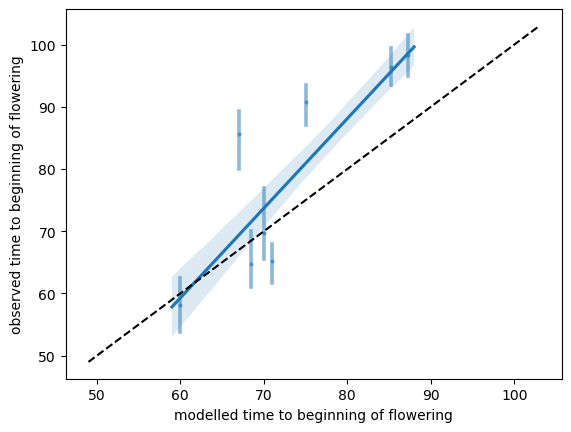

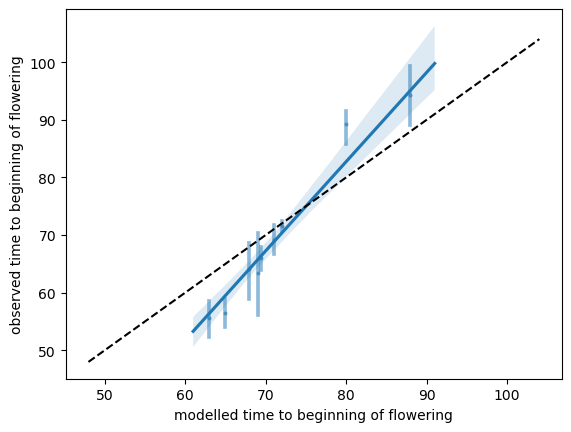

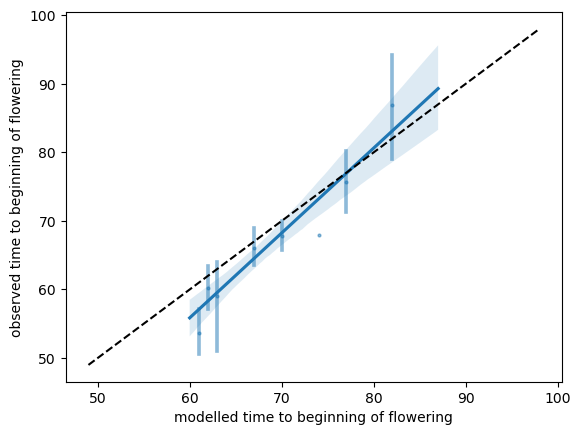

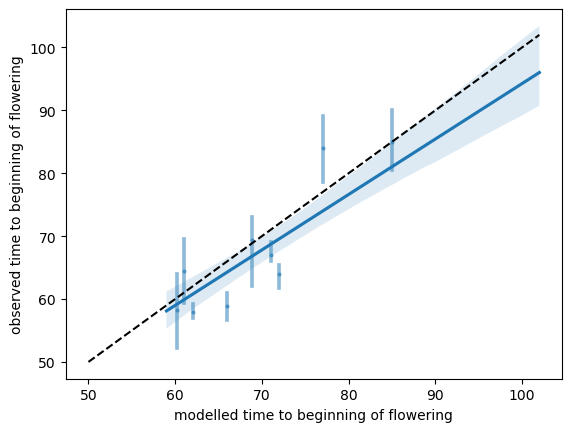

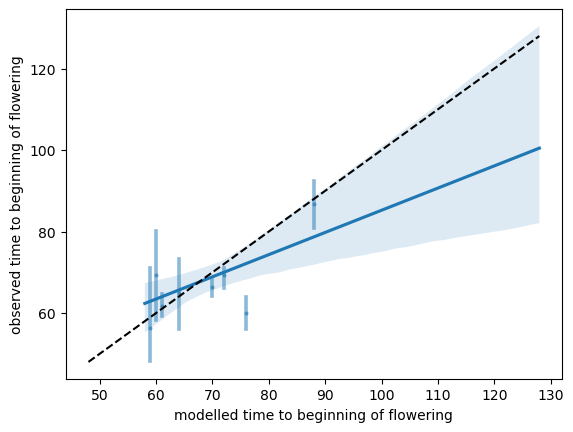

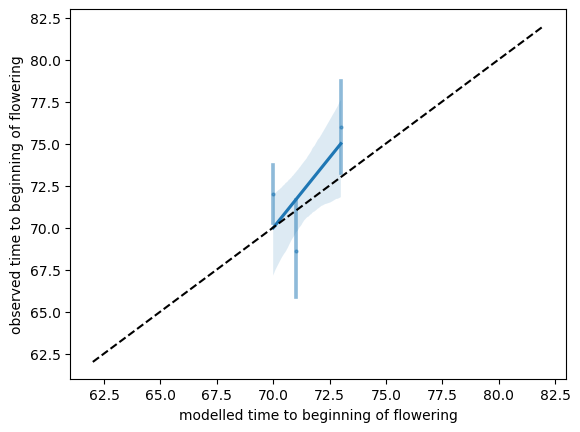

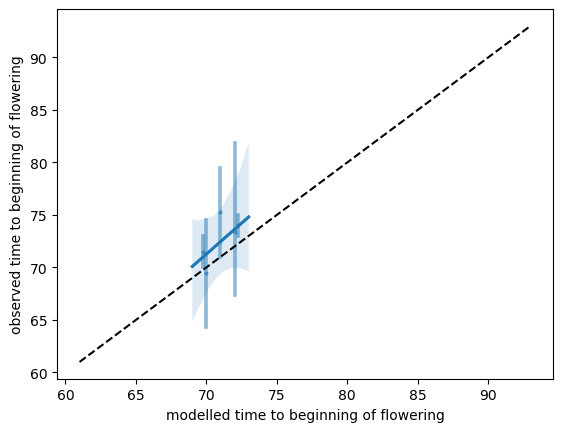

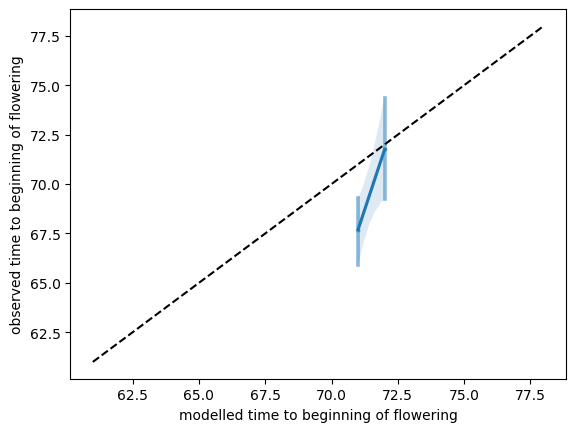

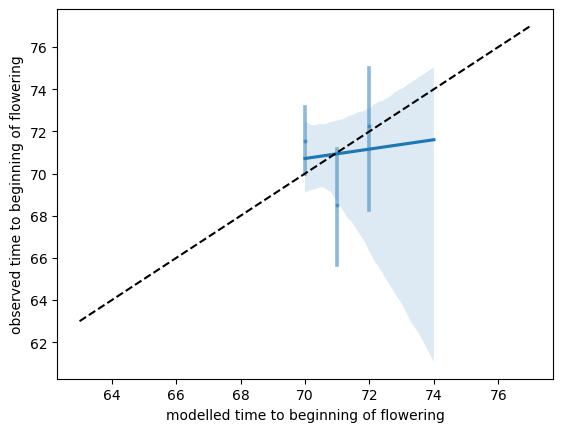

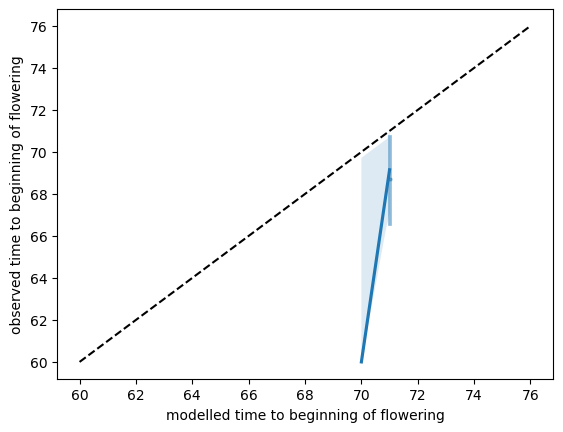

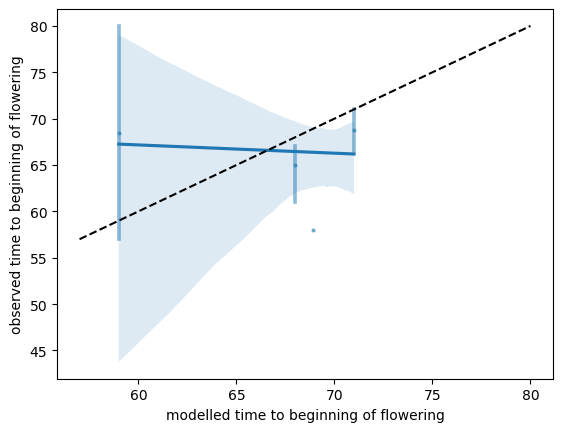

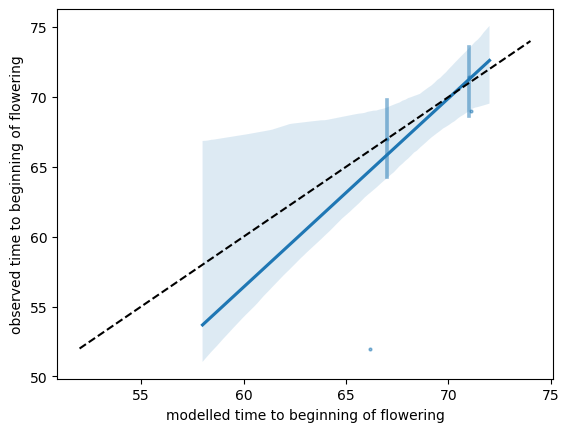

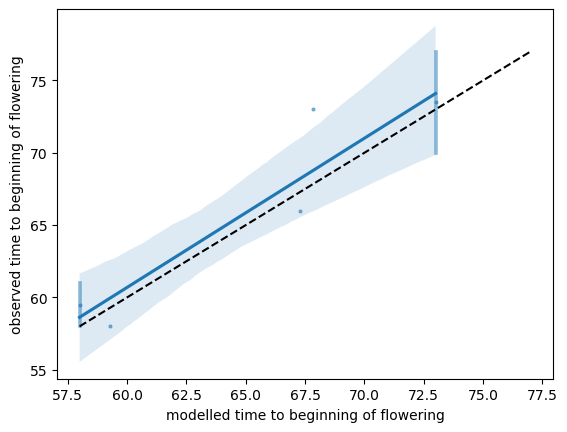

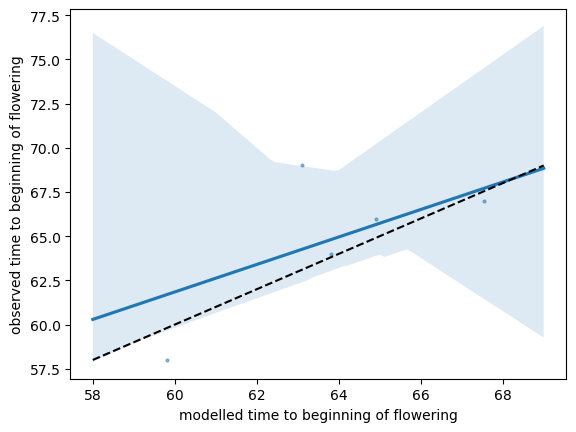

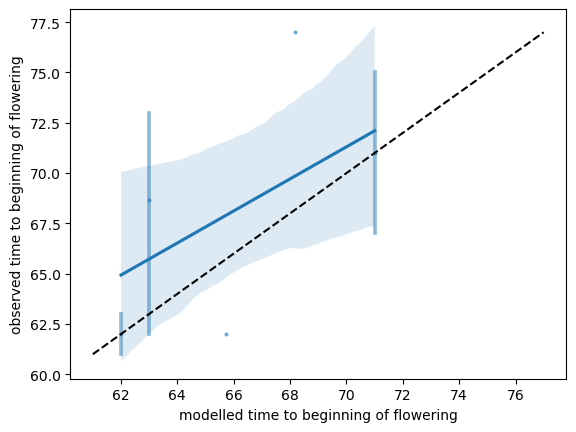

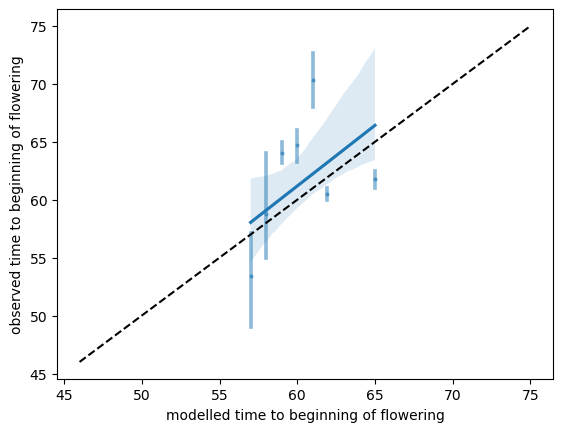

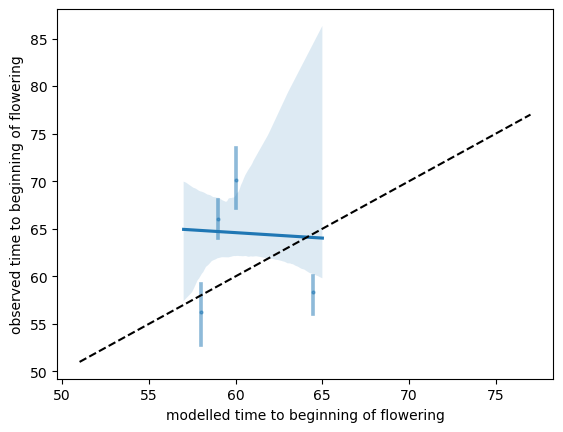

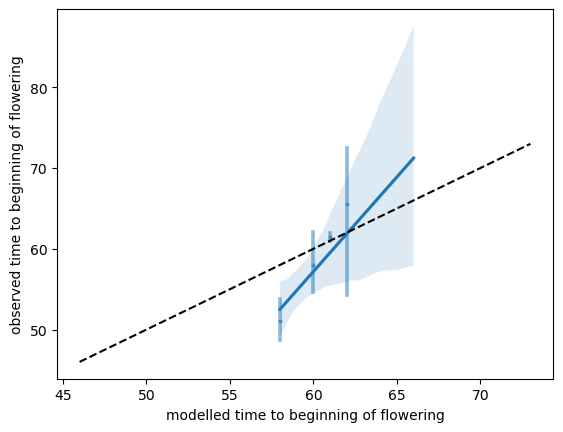

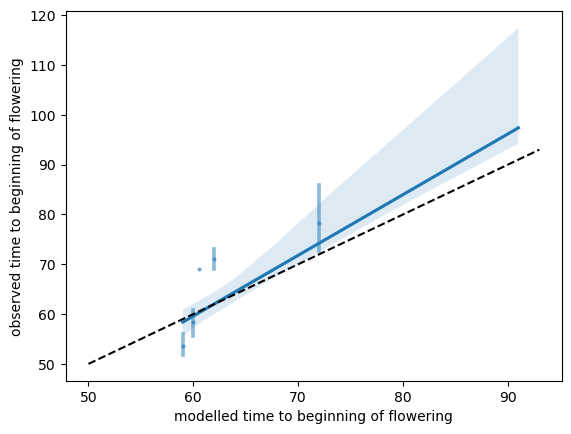

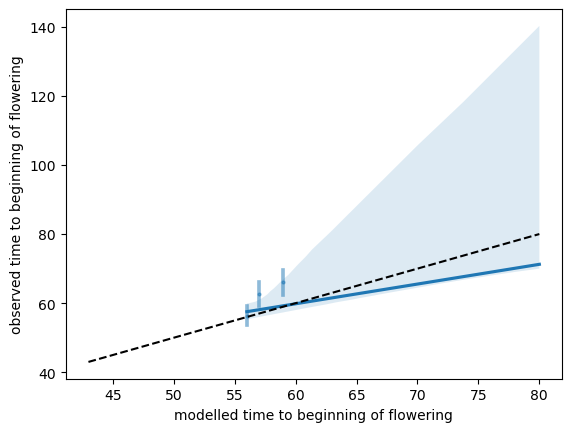

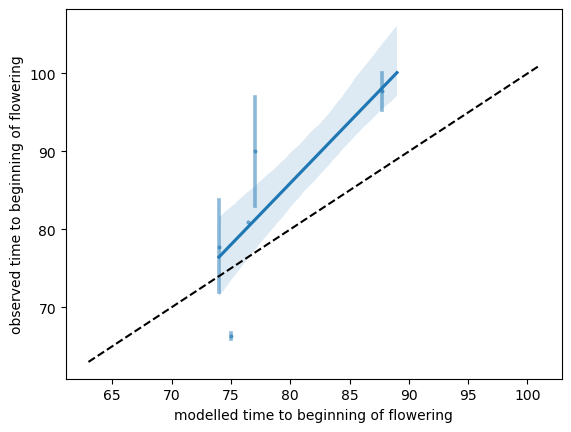

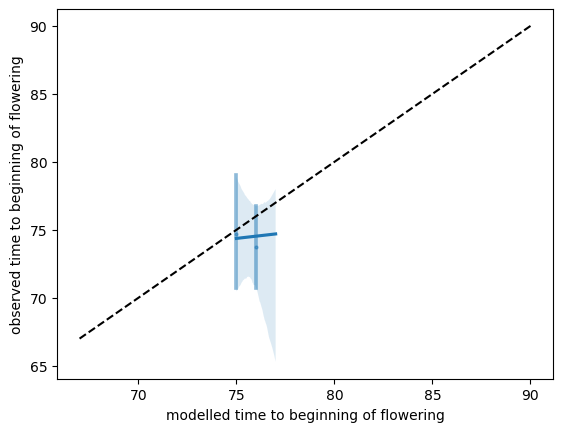

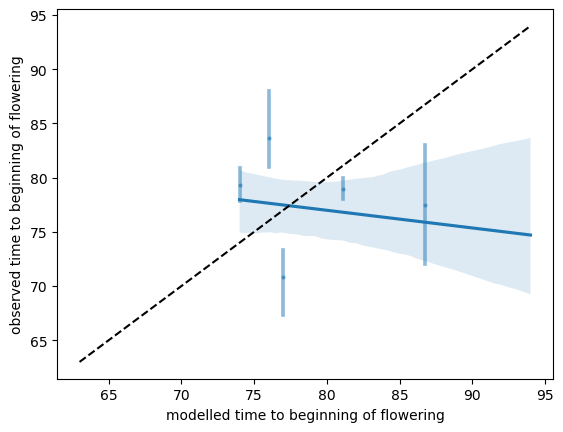

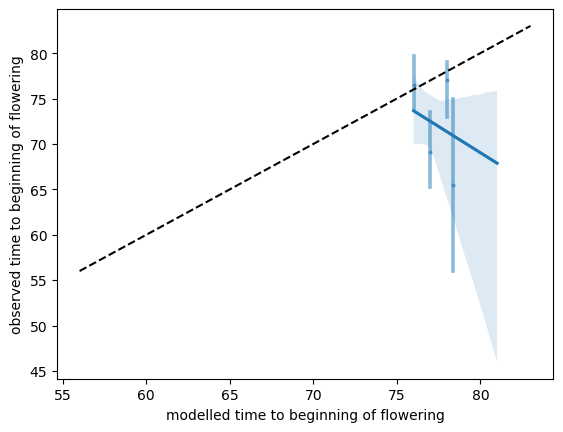

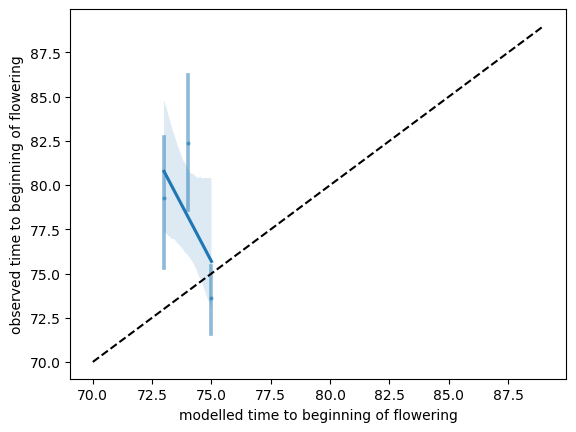

In [56]:
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
results_dict_combined = k_fold_crossval_regions(combined_variety_tests_dict, index_cols=['Stations_id', 'year'])

In [79]:
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
results_dict_combined_convolved = k_fold_crossval_regions(combined_variety_tests_dict, index_cols=['Stations_id', 'year'], 
                                                          response_type='Convolved_vary_spread', just_scale=False, plot_profiles=False,
                                                          method='Nelder-Mead', plot_corrs = False)

Fold 1 38 183 221
Optimization terminated successfully.
         Current function value: 8.403421
         Iterations: 44
         Function evaluations: 147
[ 0.5  9.3 28.3 39.2  0.8  3. ] [ 0.50277645  9.50971857 28.48933338 38.99590677  0.7816191   2.96110905] [-0.00277645 -0.20971857 -0.18933338  0.20409323  0.0183809   0.03889095]
RMSE at opt on test set:  11.89095188965565
R^2: 0.5001615746180965
Fold: 1
R2: 0.5001615746180963
Bias: 0
Variance: 88.83997155049786
Fold 2 46 175 221
Optimization terminated successfully.
         Current function value: 9.234098
         Iterations: 56
         Function evaluations: 154
[ 0.5  9.3 28.3 39.2  0.8  3. ] [ 0.49940575  9.55131768 28.62931789 38.94916052  0.7826346   2.95002917] [ 0.00059425 -0.25131768 -0.32931789  0.25083948  0.0173654   0.04997083]
RMSE at opt on test set:  7.624331759741879
R^2: 0.7093423316130739
Fold: 2
R2: 0.7093423316130739
Bias: 0
Variance: 64.91787439613528
Fold 3 45 176 221
Optimization terminated successfully.


In [93]:
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
results_dict_combined_convolved_jsp = k_fold_crossval_regions(combined_variety_tests_dict, index_cols=['Stations_id', 'year'], 
                                                          response_type='Convolved_just_spread', just_scale=False, plot_profiles=False,
                                                          method='Nelder-Mead', plot_corrs = False)

Fold 1 38 183 221
Optimization terminated successfully.
         Current function value: 8.474971
         Iterations: 22
         Function evaluations: 55
[0.5 0.8] [0.48828125 0.781875  ] [0.01171875 0.018125  ]
RMSE at opt on test set:  11.902012213774698
R^2: 0.4992312965139053
Fold: 1
R2: 0.4992312965139052
Bias: 0
Variance: 80.87980085348504
Fold 2 46 175 221
Optimization terminated successfully.
         Current function value: 9.360403
         Iterations: 20
         Function evaluations: 54
[0.5 0.8] [0.48731689 0.80805664] [ 0.01268311 -0.00805664]
RMSE at opt on test set:  8.111987908403645
R^2: 0.6709720410593774
Fold: 2
R2: 0.6709720410593772
Bias: 0
Variance: 53.54251207729467
Fold 3 45 176 221
Optimization terminated successfully.
         Current function value: 9.685979
         Iterations: 22
         Function evaluations: 55
[0.5 0.8] [0.48633423 0.82629395] [ 0.01366577 -0.02629395]
RMSE at opt on test set:  6.815016100086957
R^2: 0.6211022480058015
Fold: 3
R2: 0.6

In [97]:
combined_variety_tests_dict = {key: pd.concat((early_ds_dict[key], late_ds_dict[key])) for key in early_ds_dict.keys()}
results_dict_combined_convolved = k_fold_crossval_regions(combined_variety_tests_dict, index_cols=['Stations_id', 'year'], 
                                                          response_type='Convolved', just_scale=True, plot_profiles=False,
                                                          method='Nelder-Mead', plot_corrs = False)

Fold 1 38 183 221
 
 Func-count     x          f(x)          Procedure
    1        1.91601      52.9955        initial
    2        3.09399      59.8869        golden
    3        1.18798      41.7966        golden
    4       0.738031      24.1773        golden
    5       0.459948      9.95344        golden
    6       0.288083      48.3779        golden
    7       0.566166      12.0057        golden
    8       0.460893      9.91632        parabolic
    9       0.495702      8.52864        parabolic
   10       0.522617      9.25445        golden
   11       0.496707      8.51036        parabolic
   12       0.501424      8.55295        parabolic
   13       0.498509       8.5488        golden
   14       0.496851      8.51934        parabolic
   15       0.496334      8.51389        parabolic
   16       0.496564      8.51036        golden
   17       0.496636      8.51036        parabolic
   18       0.496608      8.51036        golden
   19       0.496592      8.51036        go

In [ ]:
no_regions_tests_dict = {'early full': ds_SSA_early,
                   'late full': ds_SSA_late}
results_dict_no_region = k_fold_crossval_regions(no_regions_tests_dict, index_cols=['Stations_id', 'year'])

In [58]:
for ind, score_dict in enumerate([results_dict_combined]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df_novar, df_novar_pooled, df_novar_full = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df_novar['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_pooled['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_full['region'] = 'all combined'
#df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test_indomain)
df_novar_pooled = pd.concat([df_novar_full, df_novar_pooled])
df_novar_pooled['Model'] = 'GDD'
df_novar_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_pooled_score_GDD.csv')

In [ ]:
for ind, score_dict in enumerate([results_dict_combined_convolved]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df_novar, df_novar_pooled, df_novar_full = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df_novar['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_pooled['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_full['region'] = 'all combined'
#df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test_indomain)
df_novar_pooled = pd.concat([df_novar_full, df_novar_pooled])
df_novar_pooled['Model'] = 'TREx just'
#df_novar_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_pooled_score_TREx.csv')

In [103]:
for ind, score_dict in enumerate([results_dict_combined_convolved_jsp]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df_novar_s, df_novar_pooled_s, df_novar_full_s = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    df_novar_s['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_pooled_s['region'] = np.array(['semiarid low', 'arid high', 'humid low', 'subhumid low', 'humid high'])#score_dict['regions']#np.array(['arid low', 'city', 'high', 'humid low'])
    df_novar_full_s['region'] = 'all combined'
#df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(no_regions_test_indomain)
df_novar_pooled_s = pd.concat([df_novar_full_s, df_novar_pooled_s])
df_novar_pooled_s['Model'] = 'TREx just\nscale optimised'
df_novar_pooled_s.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_pooled_score_TREx_js.csv')

In [82]:
#### optimising all params ####
df_novar_pooled

,Variety,R2 score,region,Model
0,combined,0.349414,all combined,TREx
0,combined,0.530493,semiarid low,TREx
1,combined,-0.267983,arid high,TREx
2,combined,0.291526,humid low,TREx
3,combined,0.307529,subhumid low,TREx
4,combined,0.014851,humid high,TREx


In [99]:
#### optimising scale ####
df_novar_pooled_s

,Variety,R2 score,region,Model
0,combined,0.316275,all combined,TREx
0,combined,0.511192,semiarid low,TREx
1,combined,-0.720486,arid high,TREx
2,combined,0.312843,humid low,TREx
3,combined,0.332799,subhumid low,TREx
4,combined,-0.015129,humid high,TREx


In [95]:
#### optimising spread and scale ####
df_novar_pooled_s

,Variety,R2 score,region,Model
0,combined,0.316275,all combined,TREx
0,combined,0.511192,semiarid low,TREx
1,combined,-0.720486,arid high,TREx
2,combined,0.312843,humid low,TREx
3,combined,0.332799,subhumid low,TREx
4,combined,-0.015129,humid high,TREx


In [33]:
df_novar_pooled_s

,Variety,R2 score,region,Model
0,combined,-1.681694,all combined,TREx
0,combined,0.518212,semiarid low,TREx
1,combined,-1.136321,arid high,TREx
2,combined,0.211292,humid low,TREx
3,combined,0.262906,subhumid low,TREx
4,combined,-1.180604,humid high,TREx


In [50]:
df_novar_pooled_s

,Variety,R2 score,region,Model
0,combined,-1.210695,all combined,TREx
0,combined,0.471859,semiarid low,TREx
1,combined,-0.234168,arid high,TREx
2,combined,0.231668,humid low,TREx
3,combined,0.176977,subhumid low,TREx
4,combined,-0.041711,humid high,TREx


In [60]:
len(ds_SSA_early)

351

In [61]:
len(ds_SSA_late)

312

In [59]:
df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(results_dict_no_region)
df_noreg_pooled['Variety'] = ['Early', 'Late']
df_noreg_pooled['Model'] = 'GDD'
df_noreg_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_regions_pooled_score_GDD.csv')

In [29]:
for ind, score_dict in enumerate([results_dict_early, results_dict_late]):
    variety = ['early', 'late'][ind]
    TL_method = ['first', 'first'][ind]
    df, df_pooled, df_full_model = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    if ind == 1:
        df['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low'])
        df_pooled['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low'])
    else:
        df['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
        df_pooled['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])#np.array(['arid low', 'city', 'high', 'humid low', 'cool'])
    df_full_model['region'] = 'all combined'
    df = pd.concat((df, df_full_model))
    df_pooled = pd.concat((df_pooled, df_full_model))
    if ind == 0:
        df_full = df
        df_pooled_full = df_pooled
    else:
        df_full = pd.concat([df_full, df])
        df_pooled_full = pd.concat([df_pooled_full, df_pooled])



In [30]:
df_pooled_full

,R2 score,Variety,region
0,0.595041,early,arid low
1,-0.096607,early,arid high
2,0.465884,early,humid low
3,0.052902,early,humid high
0,0.450801,early,all combined
0,0.621283,late,arid low
1,-0.227890,late,arid high
2,0.307537,late,humid low
3,0.063438,late,humid high
0,0.393398,late,all combined


In [31]:
for ind, score_dict in enumerate([results_dict_combined]):# results_dict_late]):
    variety = ['combined'][ind]
    TL_method = ['first', 'first'][ind]
    df_novar, df_novar_pooled, ___ = make_df_from_score_dict(score_dict, TL_method=TL_method, variety=variety)
    if ind == 1:
        df_novar['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
        df_novar_pooled['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
    else:
        df_novar['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
        df_novar_pooled['region'] = np.array(['arid low', 'arid high', 'humid low', 'humid high'])
#df_pooled = df_pooled.drop(4)

In [32]:
df_noreg, df_noreg_pooled, ___ = make_df_from_score_dict(results_dict_no_region, TL_method='GDD, no TL', variety='combined')
df_noreg['Variety'] = ['Early', 'Late']

In [33]:
df_noreg_pooled

,R2 score,Variety
0,0.358710,combined
1,0.300861,combined


In [34]:
df_novar_pooled

,R2 score,Variety,region
0,0.561934,combined,arid low
1,-0.117695,combined,arid high
2,0.332994,combined,humid low
3,0.124334,combined,humid high


In [60]:
df_noreg, df_noreg_pooled = make_df_from_score_dict(results_dict_no_region)

In [63]:
df_noreg_pooled

,R2 score,Variety
0,0.401840,NA
1,0.338325,NA


In [52]:
df_pooled['model'] = 'GDD'
#df_pooled = df_pooled.drop(4)

In [53]:
df_pooled.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_score_GDD_trust_constr.csv')

In [38]:
df_pooled_old = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_score_GDD.csv')

In [46]:
df_pooled_TL = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\combined_varieties_score_TL_new_eval.csv')
df_pooled_TL['model'] = 'TL'
#df_pooled_TL = df_pooled_TL.drop(4)

In [54]:
df_pooled_compare = pd.concat((df_pooled, df_pooled_TL))

In [55]:
df_pooled_compare

,R2 score,Variety,region,model,Unnamed: 0
0,0.371153,combined,arid low,GDD,NaN
1,0.371577,combined,city,GDD,NaN
2,0.336616,combined,high,GDD,NaN
3,0.389737,combined,humid low,GDD,NaN
0,0.663683,combined,arid low,TL,0.0
1,0.349792,combined,city,TL,1.0
2,0.239435,combined,high,TL,2.0
3,0.507505,combined,humid low,TL,3.0


In [175]:
df, df_pooled = make_df_from_score_dict(results_dict_final)

In [67]:
df_full = df_full.drop(4)
df_pooled_full = df_pooled_full.drop(4)

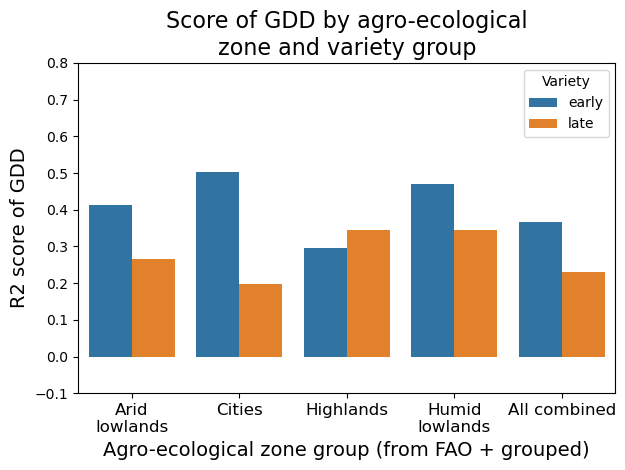

In [74]:
font_size = 14
fig, ax = plt.subplots()
sns.barplot(data = df_pooled_full, hue = 'Variety', x = 'region', y='R2 score', ax=ax)
ax.set_xticks(range(5), ['Arid\nlowlands', 'Cities', 'Highlands', 'Humid\nlowlands', 'All combined'], fontsize =font_size - 2)
ax.set_ylabel('R2 score of GDD', fontsize =font_size)
ax.set_xlabel('Agro-ecological zone group (from FAO + grouped)', fontsize =font_size)
ax.set_title('Score of GDD by agro-ecological\nzone and variety group', fontsize = font_size +2)
ax.set_ylim((-0.1, 0.8))
fig.tight_layout()

In [184]:
df_pooled_full.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\TL_tests\\split_varieties_pooled_score_GDD.csv')

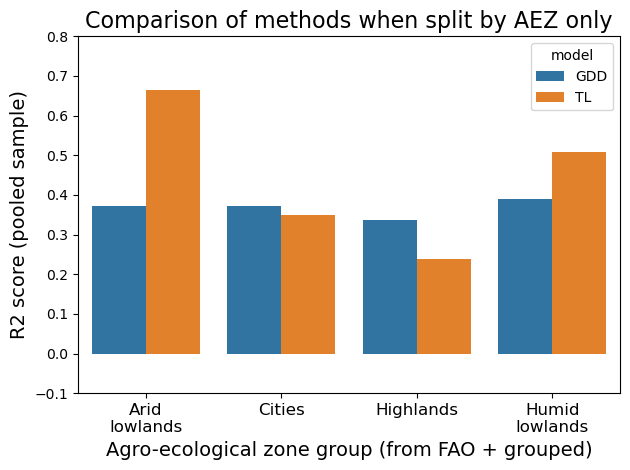

In [73]:
font_size = 14
fig, ax = plt.subplots()
sns.barplot(data = df_pooled_compare, hue = 'model', x = 'region', y='R2 score', ax=ax)
ax.set_xticks(range(4), ['Arid\nlowlands', 'Cities', 'Highlands', 'Humid\nlowlands'], fontsize =font_size - 2)
ax.set_ylabel('R2 score (pooled sample)', fontsize =font_size)
ax.set_xlabel('Agro-ecological zone group (from FAO + grouped)', fontsize =font_size)
ax.set_title('Comparison of methods when split by AEZ only', fontsize = font_size +2)
ax.set_ylim((-0.1, 0.8))
fig.tight_layout()

In [44]:
df_pooled_compare

,Unnamed: 0,R2 score,Variety,model,region
0,0,0.262182,NaN,GDD,NaN
1,1,0.373611,NaN,GDD,NaN
2,2,0.344686,NaN,GDD,NaN
0,0,0.687313,combined,TL,arid low
1,1,0.475974,combined,TL,city
2,2,0.276932,combined,TL,high
3,3,0.554763,combined,TL,humid low


In [69]:
score_dict = results_dict_early
SSE_all_reg = np.array(score_dict['SSEs'])
obsvars_all_reg = np.array(score_dict['observed variances'])
length_all_reg = np.array(score_dict['fold lengths'])
MSE_all_reg = SSE_all_reg.sum(axis=0)/length_all_reg.sum(axis = 0)
R2_all_reg = 1 - (SSE_all_reg/((length_all_reg - 1)*obsvars_all_reg))

In [58]:
early_ds_dict.keys()

dict_keys(['arid low', 'city', 'arid high', 'humid low', 'humid high'])

In [71]:
np.round(R2_all_reg, decimals=2)#.mean(axis=1)

array([[  0.53,   0.33,  -0.78,   0.04,  -0.63],
       [  0.53,   0.8 ,  -0.37,   0.8 ,   0.93],
       [ -0.32,  -0.07,  -0.14,  -0.11, -10.48],
       [  0.48,   0.25,   0.29,   0.4 ,   0.09],
       [  0.05,   0.  ,   0.12,   0.26,   0.32]])

In [72]:
def kfold_df_from_array(array):
    df = pd.DataFrame({'arid lowlands': array[0, :],
                       'arid highlands': array[2, :],
                       'humid lowlands': array[3, :],
                       'humid highlands': array[4, :],
                       'cities': array[1, :]})
    return df

In [73]:
df_early_GDD = kfold_df_from_array(R2_all_reg)

In [74]:
df_early_GDD.to_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\early_vars_split_scores.csv')

(-1.0, 1.0)

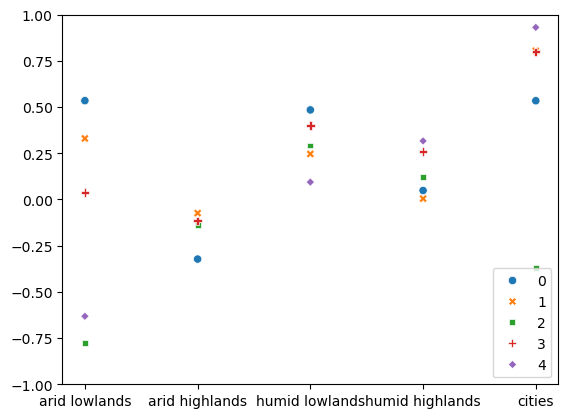

In [76]:
fig, ax =plt.subplots()
sns.scatterplot(data = df_early_GDD.T, ax=ax)
ax.set_ylim((-1, 1))

In [66]:
for method_ind in range(2):
    score_dict = [results_dict_early, results_dict_late][method_ind]
    variety = ['early', 'late'][method_ind]
    TL_method = ['NA', 'NA'][method_ind]
    R2s = skill_score_all_reg(score_dict)
    scores_by_set_method = pd.DataFrame({'Variety': [variety],
                              'TL method': [TL_method],
                              'R2 Fold 1': [R2s[0]],
                              'R2 Fold 2': [R2s[1]],
                              'R2 Fold 3': [R2s[2]],
                              'R2 Fold 4': [R2s[3]],
                              'R2 Fold 5': [R2s[4]]})
    if method_ind == 0:
        scores_full = scores_by_set_method
    else: scores_full = pd.concat((scores_full, scores_by_set_method),axis=0)

In [67]:
scores_full.loc[:, [f'R2 Fold { n + 1}' for n in range(5)]].values.mean(axis=1)

array([0.16689569, 0.11970848])

In [68]:
scores_full

,Variety,TL method,R2 Fold 1,R2 Fold 2,R2 Fold 3,R2 Fold 4,R2 Fold 5
0,early,NA,0.477267,0.346754,-0.043224,0.285039,-0.231358
0,late,NA,0.394753,0.142984,0.327125,-0.145893,-0.120428


In [87]:
def run_GDD(x, ds, driver_variable, latlon_proj = True, response_type = 'Trapezoid', 
                             phase_list = ['beginning of flowering'], exclude_unfinished = False,
                             growing_period_length = 300, thresholds = [100], 
                             title_extra='', method='scatter', savename = False, plot=False, col='blue',
                             index_cols = ['lat', 'lon', 'Management', 'vargroup', 'Stations_id', 'year'],
                             step = 0.25): 
    #Change index_cols to ['year', 'Stations_id'] if using DE dataset
    len_index_cols = len(index_cols)
    if response_type == 'Trapezoid':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Trapezoid_Temp_response(meantemp, x[1], x[2], 0.2, 3)#x[3], x[4])
    elif response_type == 'Wang':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
    elif response_type == 'Convolved':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), 8, 3)#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], 3)
        table = scipy.ndimage.gaussian_filter(table2, 8/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
    elif response_type == 'Convolved_vary_spread':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), x[1], x[2], x[3], x[5])
        table = scipy.ndimage.gaussian_filter(table2, x[4]*10/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
    elif response_type == 'Convolved_just_spread':
        #table = vec_expint(x[1], x[2], x[3], np.arange(0, 50, 0.5), x[4], x[5])#, x[4], x[5])#x[2]
        table2 = Convolved_Wang_Engel(np.arange(-10, 50, step), 9.3, 28.3, 39.2, 3)
        table = scipy.ndimage.gaussian_filter(table2, x[1]*10/step, mode='constant', cval = 0, axes=0)
        def response(meantemp):
            return x[0]*table[(np.round(meantemp/step, decimals = 1)).astype(int) + int(10/step)]*(meantemp > -10)
        #def response(meantemp):
        #    return x[0]*table[(np.round(meantemp/5, decimals = 1)*10).astype(int)]*(meantemp > 0)
    elif response_type == 'multi_phase':
        def response(meantemp):
            #return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
            return x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3])
        responses = [lambda meantemp: x[0]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[1], x[2], x[3]),
                     lambda meantemp: x[4]*modelling_fctns.Wang_Engel_Temp_response(meantemp, x[5], x[6], x[7])]
    driver_columns = [f'{driver_variable} at day {day}' for day in range(growing_period_length)]
    ds_for_model = ds[driver_columns + index_cols].copy()
    #ds_for_model.loc[:, driver_columns] = ds_for_model.loc[:, driver_columns]#.round(decimals = 10).astype(np.float64)
    if response_type == 'multi_phase':
        t_dev = np.zeros(len(ds_for_model))
        for i, colm in enumerate(driver_columns):
            resp = modelling_fctns.phase_dependent_response2(ds_for_model.loc[:, colm], t_dev, responses, thresholds)
            #resp2 = response(ds_for_model.loc[:, colm])
            #if np.any(resp != resp2):
            #    print(resp, resp2)
            #print(resp)
            t_dev += resp
            ds_for_model.loc[:, colm] = t_dev
    else:
        ds_for_model.loc[:, driver_columns] = response(ds_for_model[driver_columns]).cumsum(axis=1)
    model_dev_time_series = ds_for_model.values.T
    column_names = [np.array([f'modelled time to {phase}' for phase in phase_list]+ index_cols)]
    thresholds_for_phase = thresholds[-1:]
    #print(thresholds_for_phase, model_dev_time_series.shape[1])
    phase_dates_array = np.zeros((len(thresholds_for_phase), model_dev_time_series.shape[1]))#
    for obs_index in range(model_dev_time_series.shape[1]):
        #print(model_dev_time_series[:-2, obs_index])
        #print(model_dev_time_series[:-len_index_cols, obs_index])#.astype(np.float64))
        phase_dates_array[:, obs_index] = np.digitize(thresholds_for_phase, model_dev_time_series[:-len_index_cols, obs_index].astype(np.float64))    
    #print(phase_dates_array)
    phase_dates_array = np.concatenate([phase_dates_array, *[[model_dev_time_series[-(k + 1)]] for k in reversed(range(len_index_cols))]], axis=0)
    #print(column_names)
    phase_dates_array = pd.DataFrame(phase_dates_array.T, columns = column_names[0])
    #print(ds.columns.to_list(), phase_dates_array.columns.to_list())
    comparison_array = ds.T.drop_duplicates().T.merge(phase_dates_array, how='left', on=index_cols).dropna(how='all')
    #print(len(comparison_array), len(ds), len(phase_dates_array))
    if plot:
        plot_from_comparison_array(comparison_array, title_extra=title_extra, method=method, savename=savename, 
                                  phase_list=phase_list, exclude_unfinished=exclude_unfinished, growing_period_length=growing_period_length,
                                  col=col)
    return comparison_array